In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# FD

In [ ]:
!pip install pyefd --quiet

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


['calf.png', 'cat.png', 'cow.png', 'dog.png', 'fish.png', 'donkey.png', 'fox.png', 'rabbit.png']
/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/calf.png


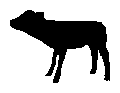

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cat.png


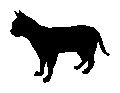

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cow.png


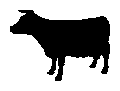

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/dog.png


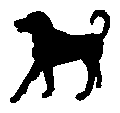

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fish.png


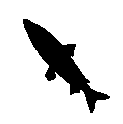

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/donkey.png


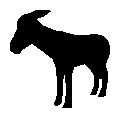

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fox.png


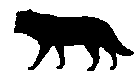

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/rabbit.png


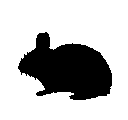

In [ ]:
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"

from google.colab.patches import cv2_imshow
import cv2
import os
filelist = os.listdir(work_path + 'Data/Animal_Data/')
print(filelist)

for file in filelist:
  print(work_path + 'Data/Animal_Data/' + file)
  img = cv2.imread(work_path + 'Data/Animal_Data/' + file, cv2.IMREAD_GRAYSCALE)
  # cv2_imshow(img)

  _, binary_image = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
  cv2_imshow(img)


Contour for all images.

['calf.png', 'cat.png', 'cow.png', 'dog.png', 'fish.png', 'donkey.png', 'fox.png', 'rabbit.png']
/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/calf.png


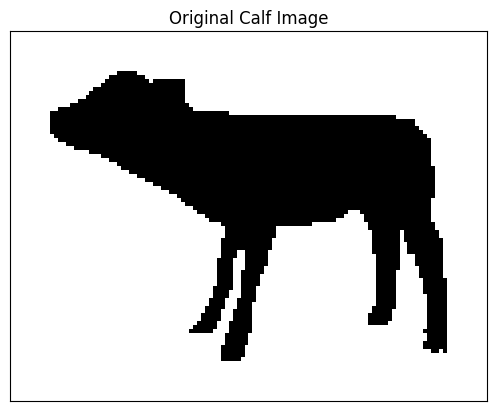

Number of points in Calf
200


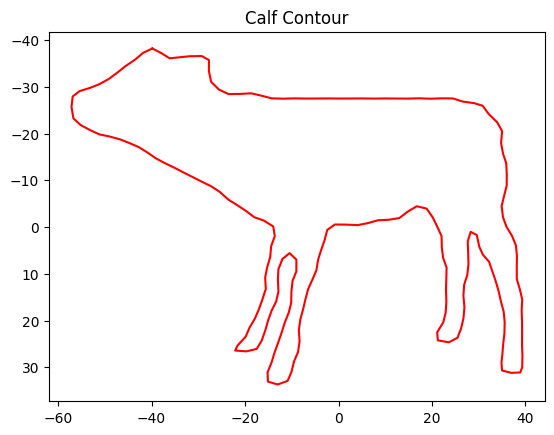

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cat.png


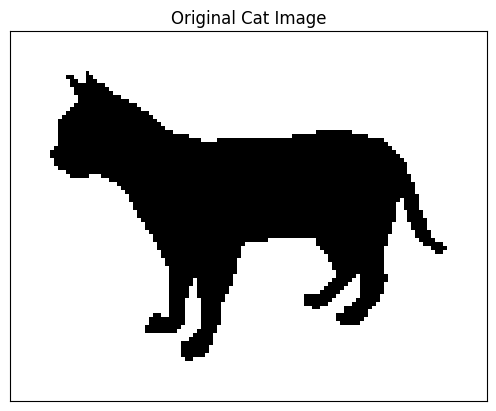

Number of points in Cat
200


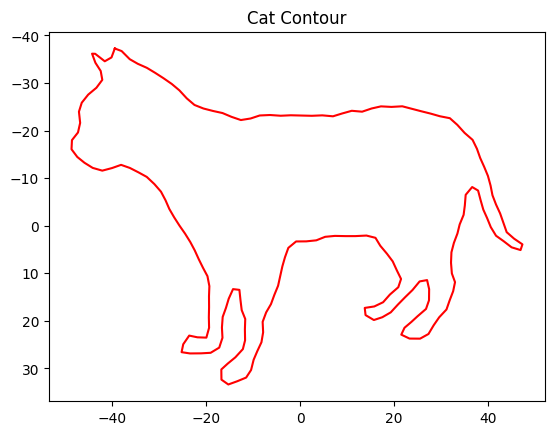

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cow.png


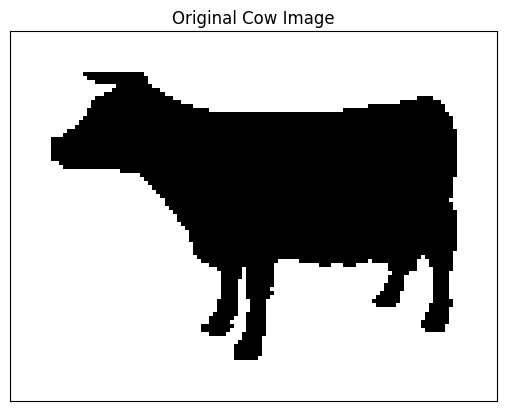

Number of points in Cow
200


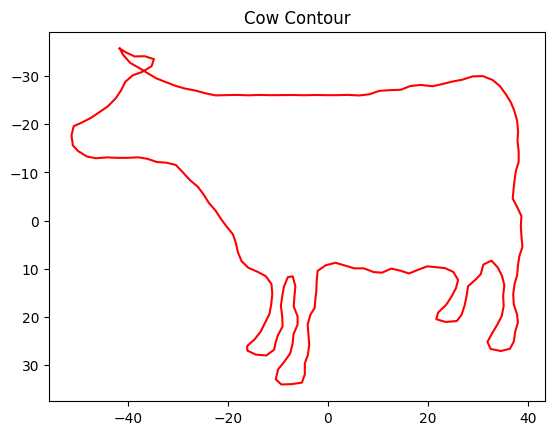

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/dog.png


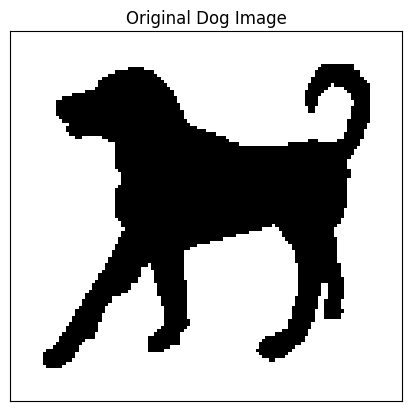

Number of points in Dog
200


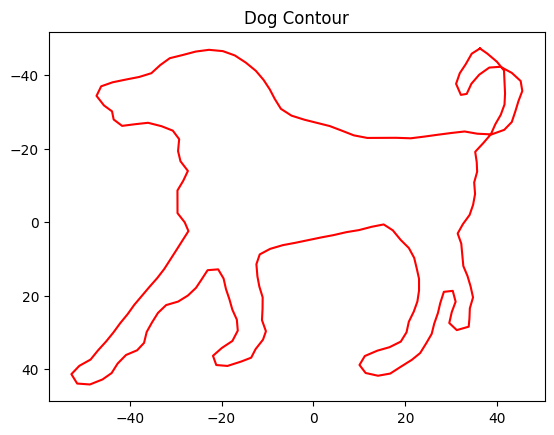

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fish.png


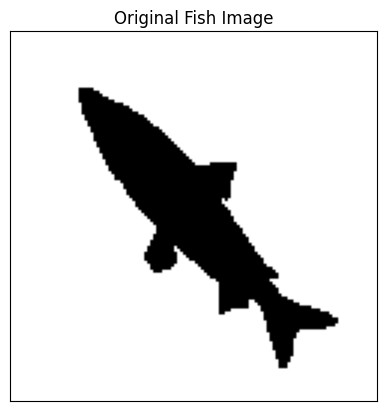

Number of points in Fish
200


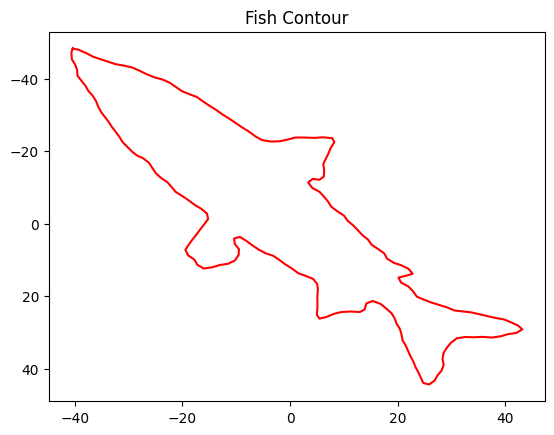

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/donkey.png


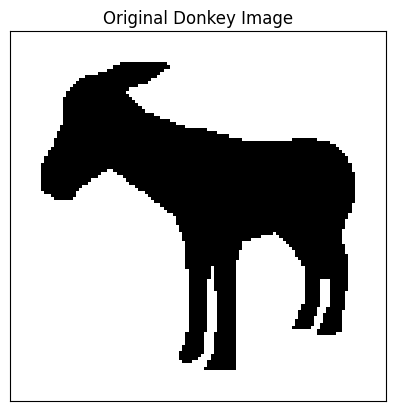

Number of points in Donkey
200


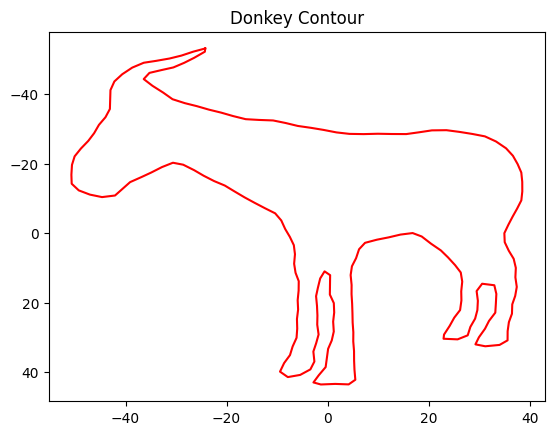

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fox.png


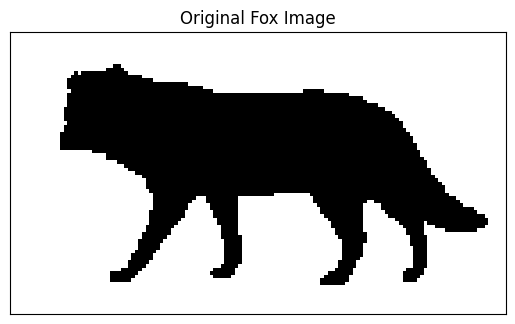

Number of points in Fox
200


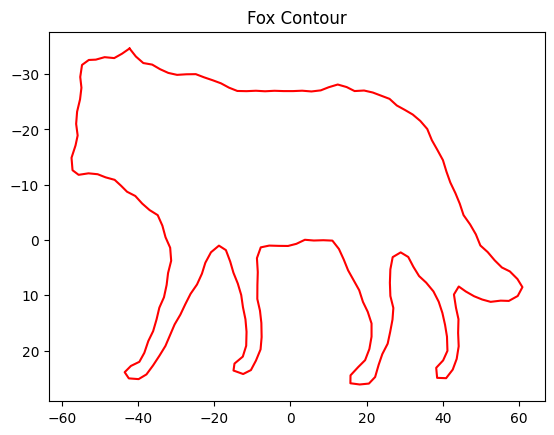

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/rabbit.png


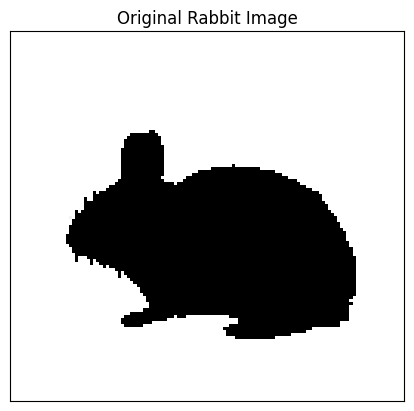

Number of points in Rabbit
200


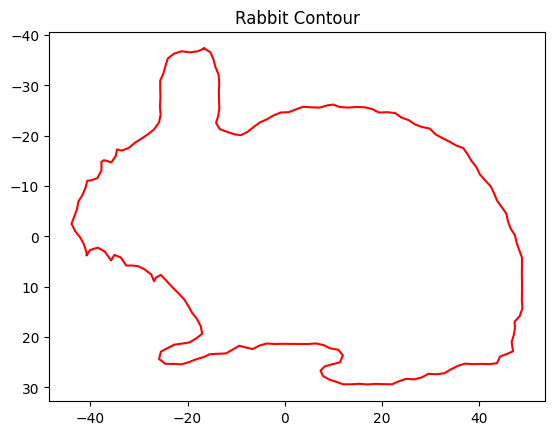

In [ ]:
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow
import cv2
import os
from pyefd import elliptic_fourier_descriptors
from scipy import linalg
from pyefd import reconstruct_contour


filelist = os.listdir(work_path + 'Data')
print(filelist)

contour_list = []
animal_list = []

for file in filelist:
    print(work_path + 'Data/' + file)
    img = cv2.imread(work_path + 'Data/' + file, cv2.IMREAD_GRAYSCALE)

    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title('Original ' + file[:-4].capitalize() + ' Image')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    _, binary_image = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # Find contours in the binary image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)

    coeffs = elliptic_fourier_descriptors(np.squeeze(contour), order=80)  # Adjust the order as needed

    reconstructed_contour = reconstruct_contour(coeffs, locus=(0, 0), num_points=200)
    print('Number of points in ' + file[:-4].capitalize())
    print(reconstructed_contour.shape[0])
    plt.figure()
    plt.plot(reconstructed_contour[:, 0], reconstructed_contour[:, 1],'r')
    plt.gca().invert_yaxis()
    plt.title(file[:-4].capitalize() + ' Contour')
    # plt.xticks([])
    # plt.yticks([])
    plt.show()

    animal_list.append(file[:-4])
    contour_list.append(reconstructed_contour)



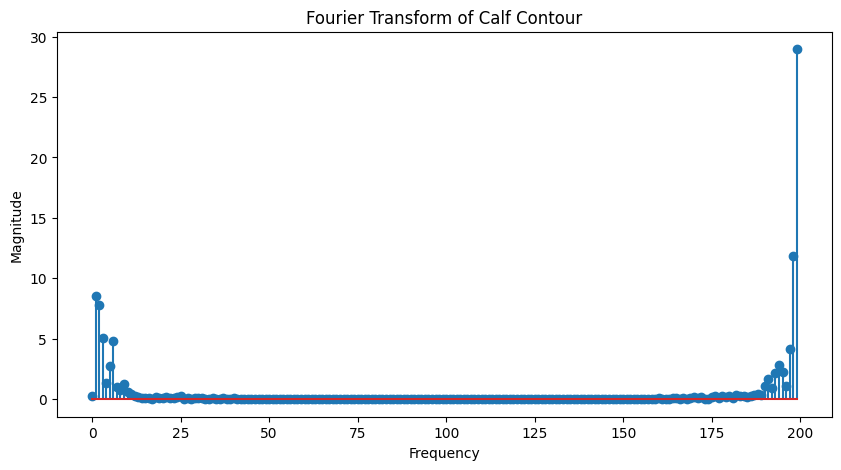

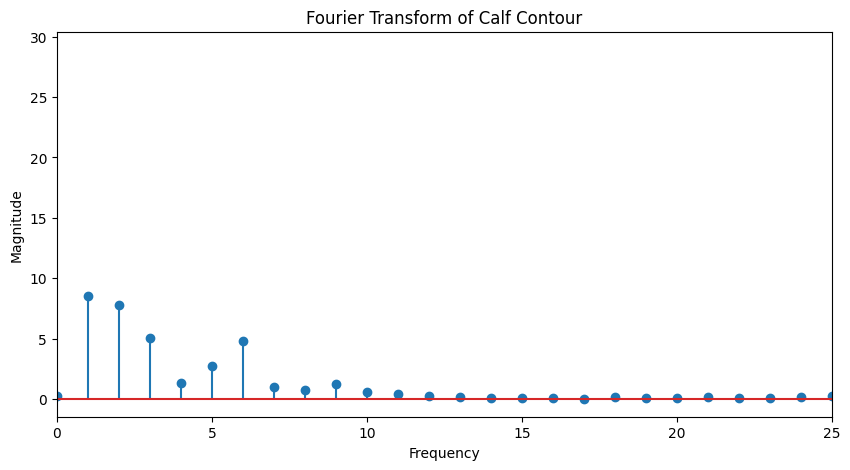

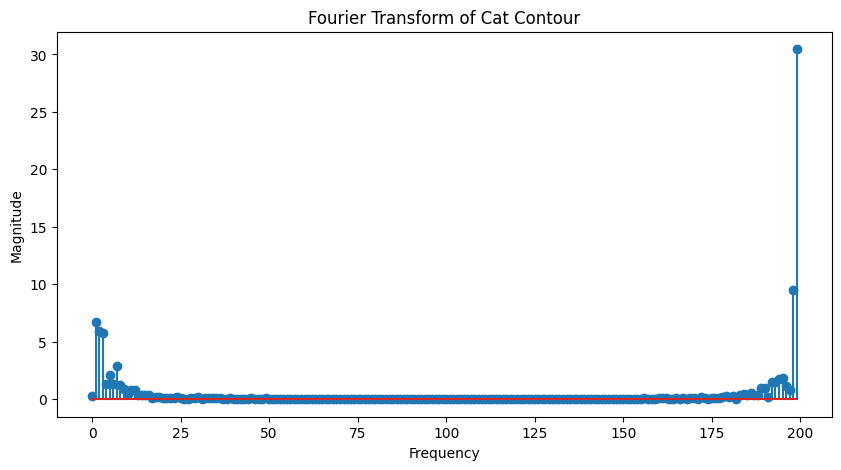

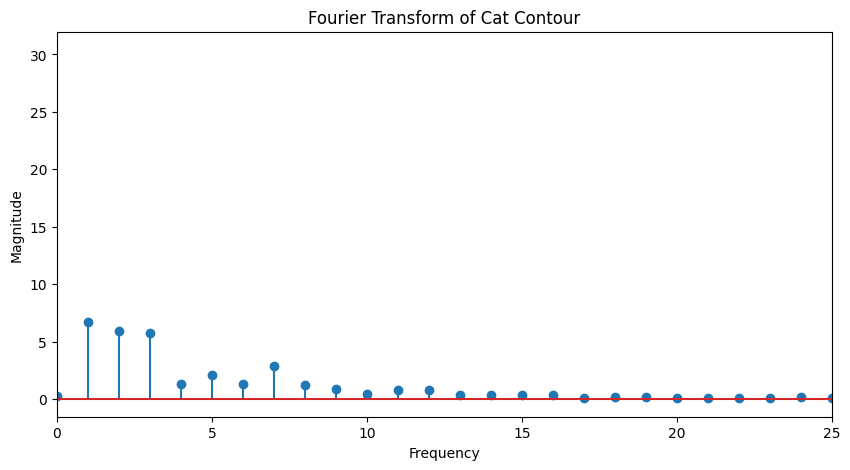

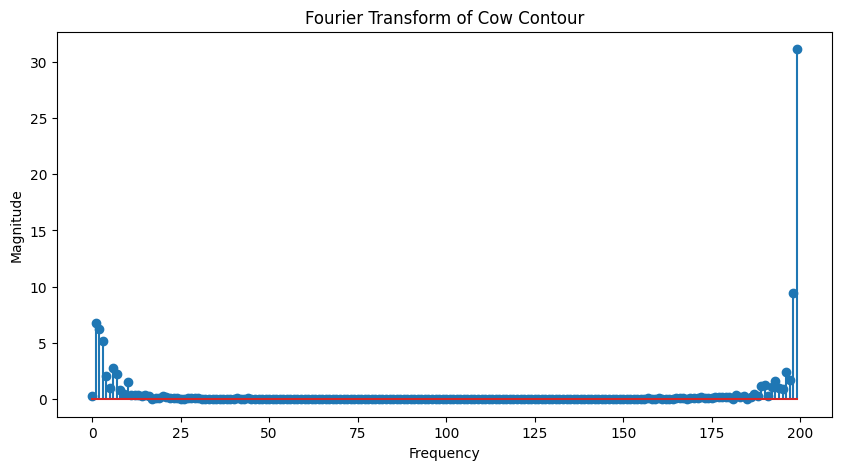

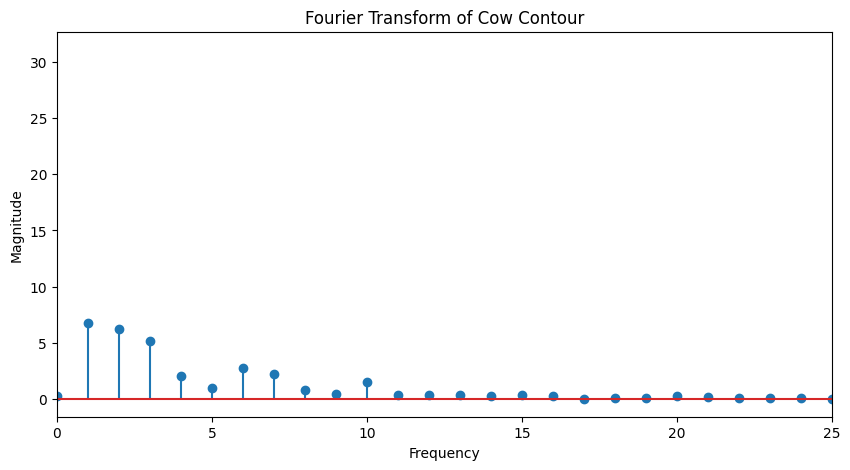

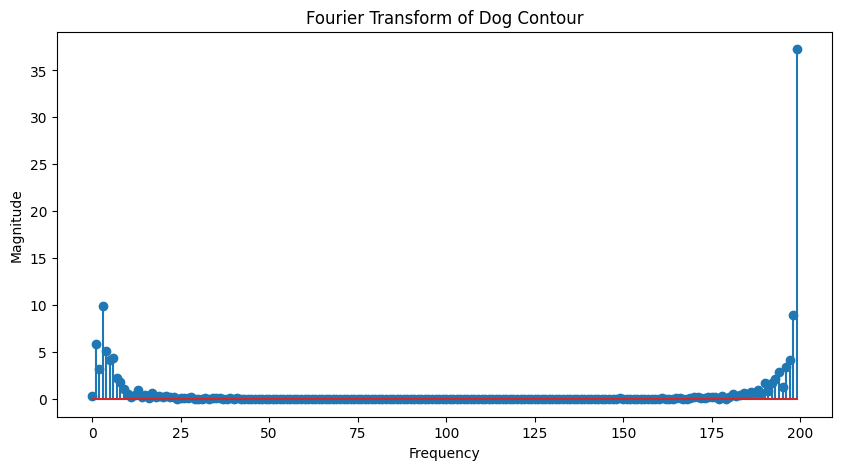

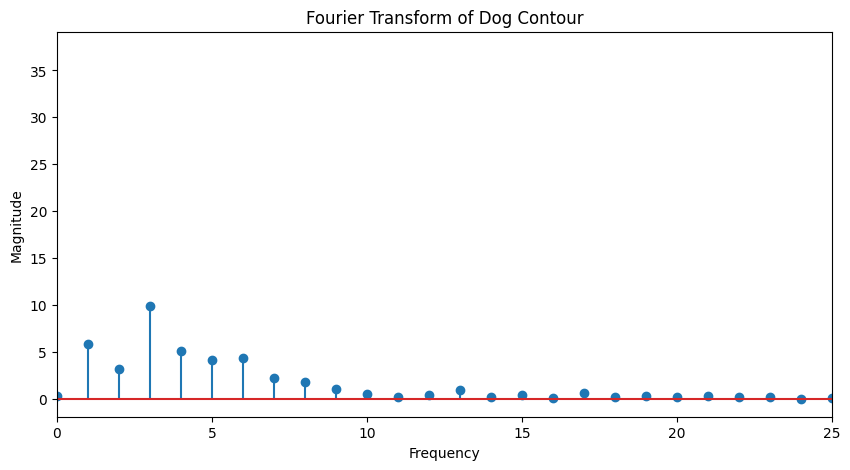

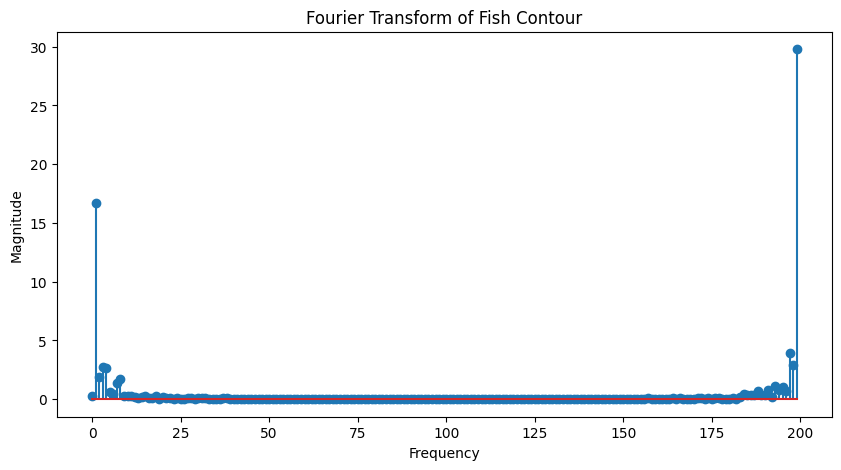

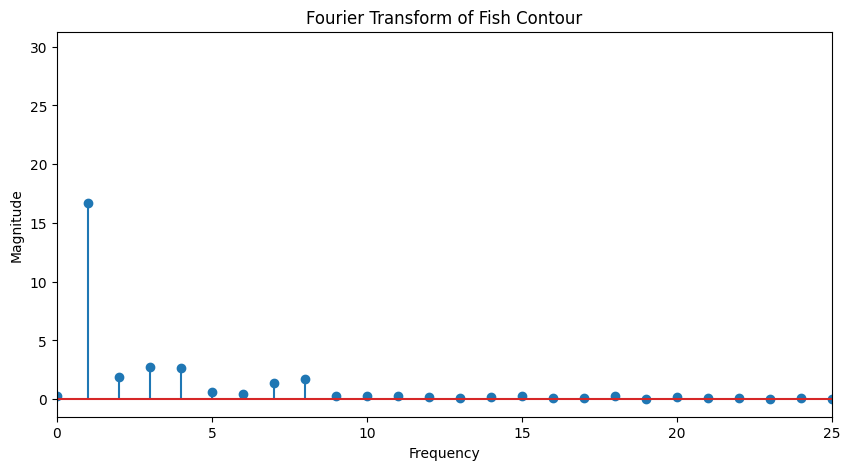

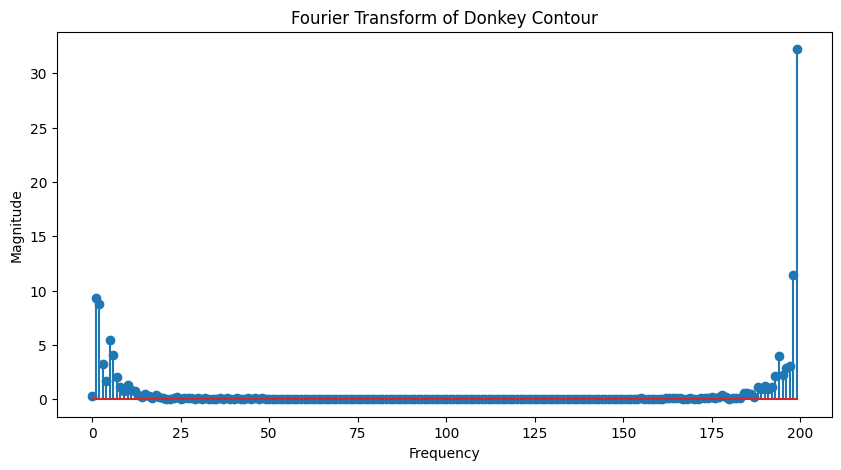

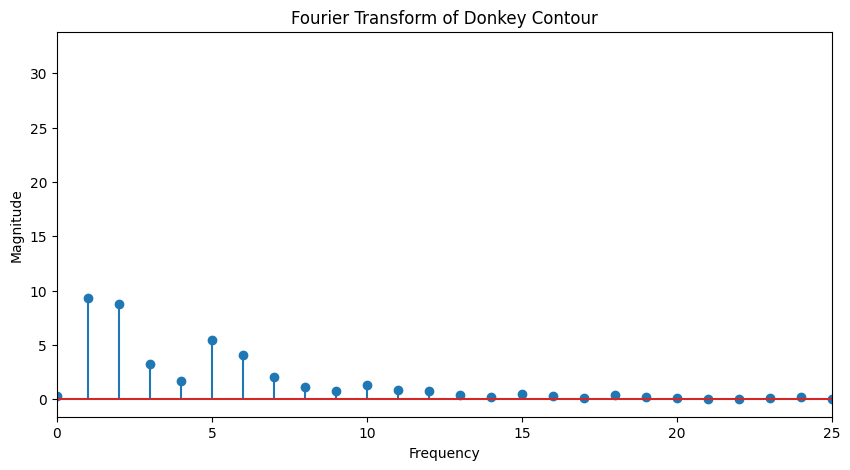

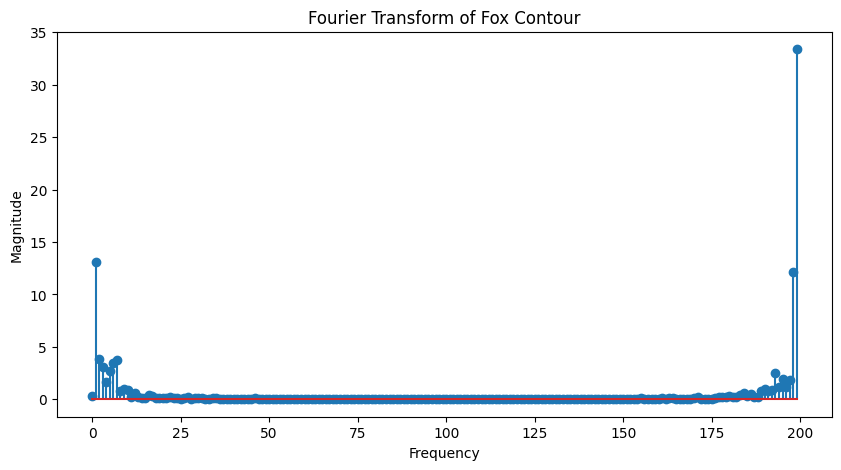

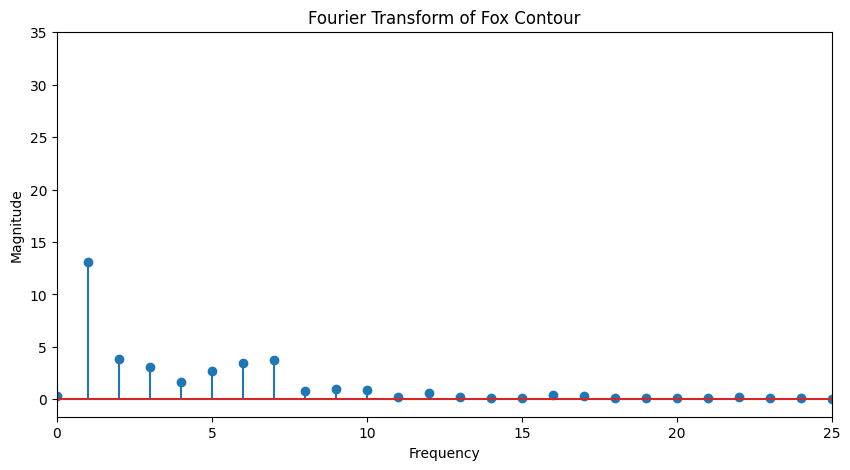

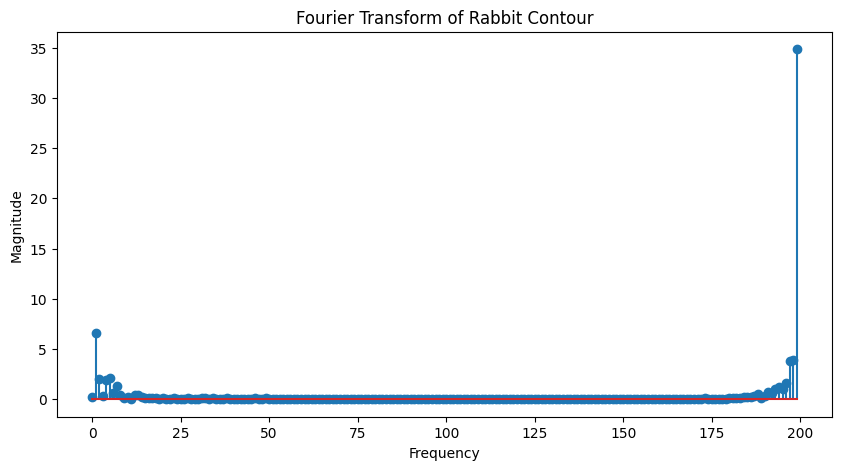

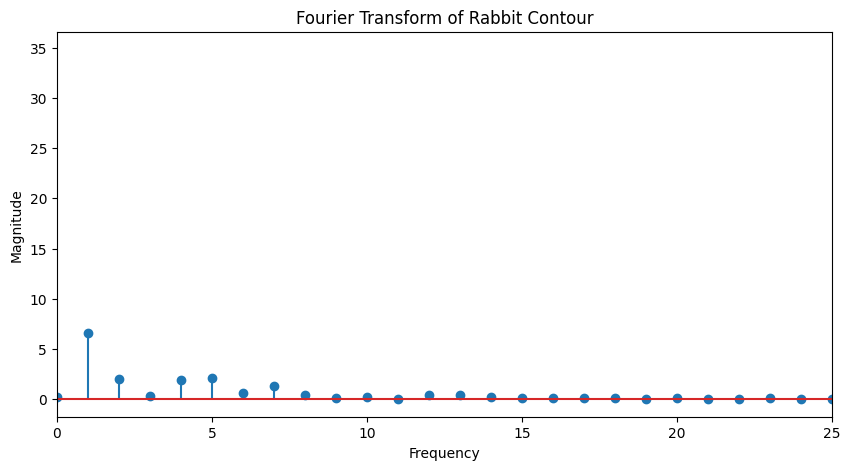

In [ ]:
import numpy as np
import cv2
from skimage import measure
import matplotlib.pyplot as plt
from pyefd import elliptic_fourier_descriptors
from scipy import linalg
from pyefd import reconstruct_contour


fft_list = []
for cont, animal in zip(contour_list, animal_list):

    contour_complex = np.array(cont, dtype=np.complex128)
    contour_complex = contour_complex[:, 0] + 1j * contour_complex[:, 1]

    # Compute FFT
    fft_result = np.fft.fft(contour_complex) / 200

    fft_list.append(np.abs(fft_result))

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, 25)
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.show

original_fft = fft_list.copy()

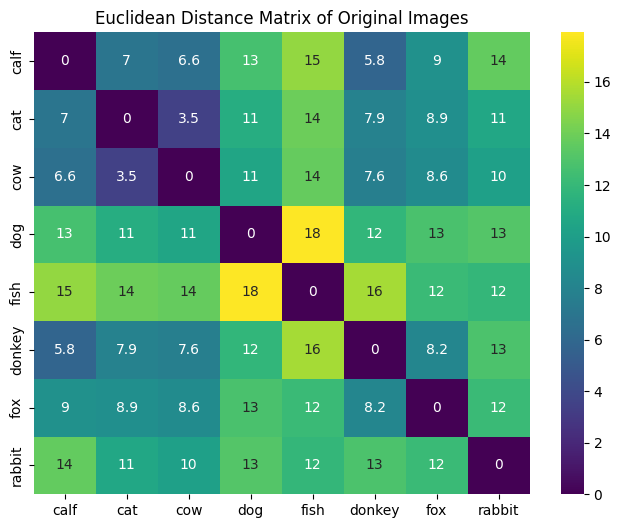

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def plot_euclidean_distance_table(data, title):
    """Plots a heatmap of the Euclidean distance matrix for a list of arrays."""

    # Calculate pairwise Euclidean distances
    distances = pdist(data, metric='euclidean')

    # Create a square distance matrix
    distance_matrix = squareform(distances)

    # Create a DataFrame for better visualization
    df_distance = pd.DataFrame(distance_matrix)

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_distance, annot=True, cmap="viridis")
    plt.title(title)
    plt.xticks([x + 0.5 for x in range(8)], animal_list)
    plt.yticks([x + 0.5 for x in range(8)], animal_list)
    plt.show()


# Plot the distance table
plot_euclidean_distance_table(fft_list, 'Euclidean Distance Matrix of Original Images')

# FD with Rotation

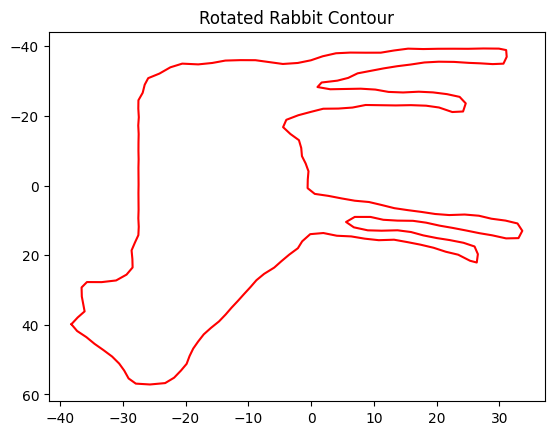

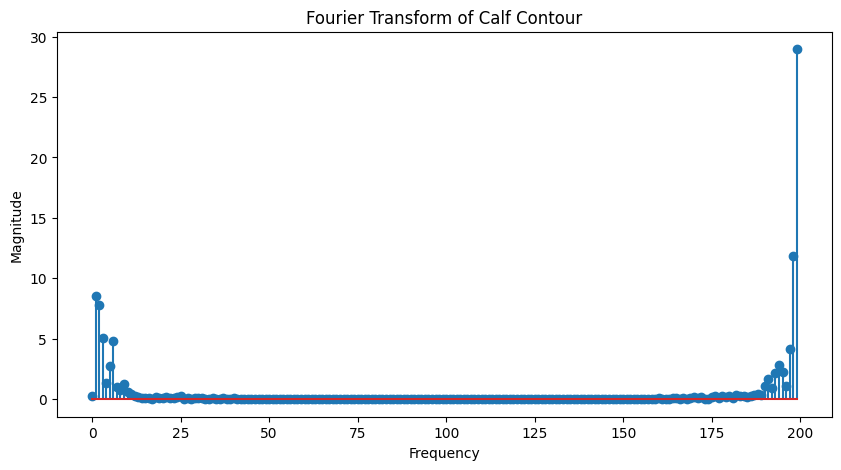

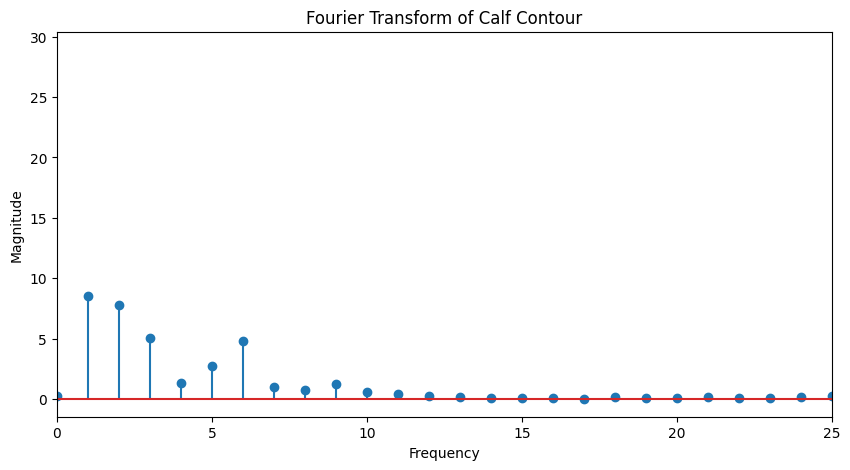

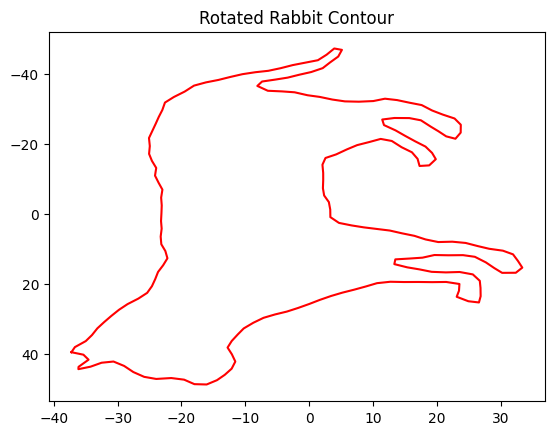

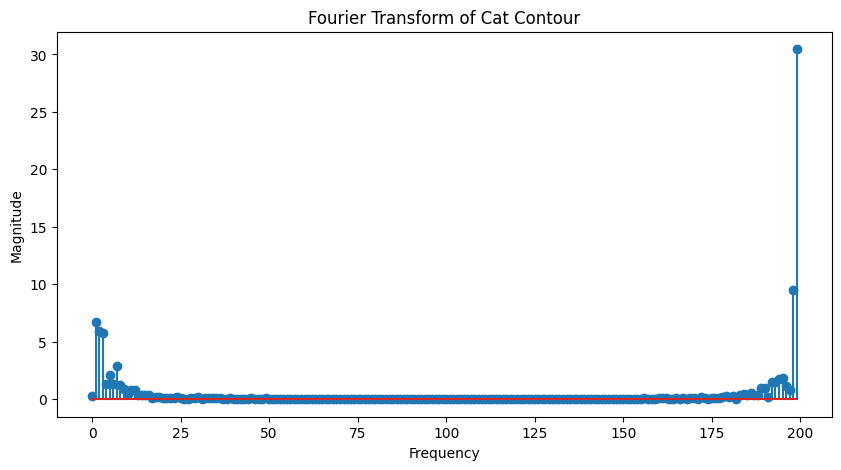

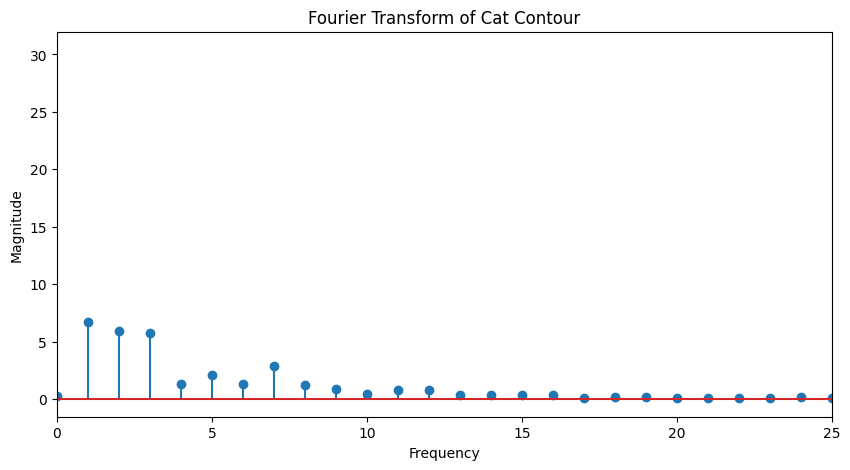

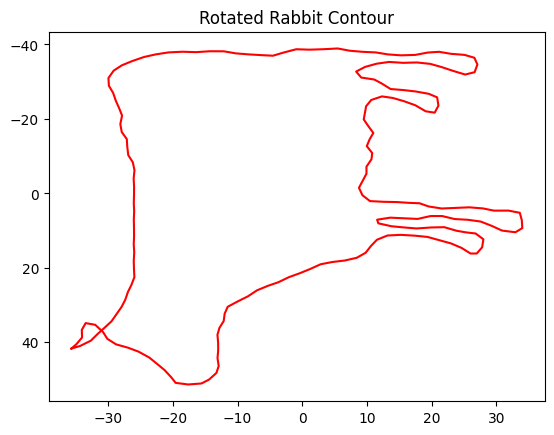

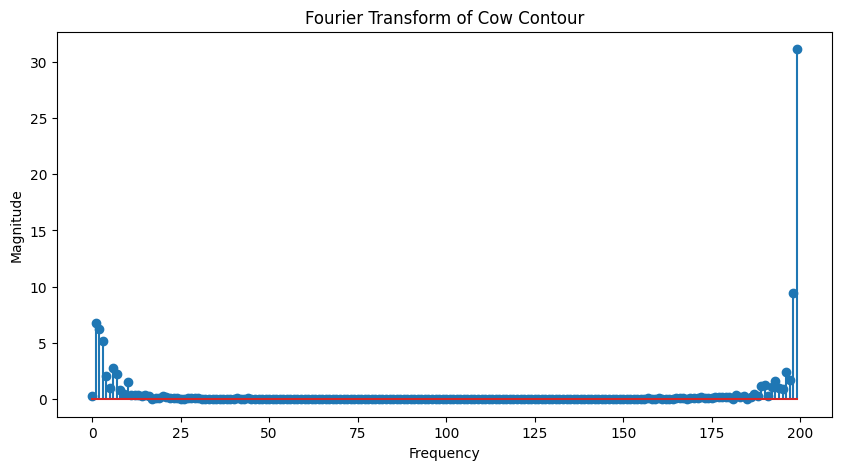

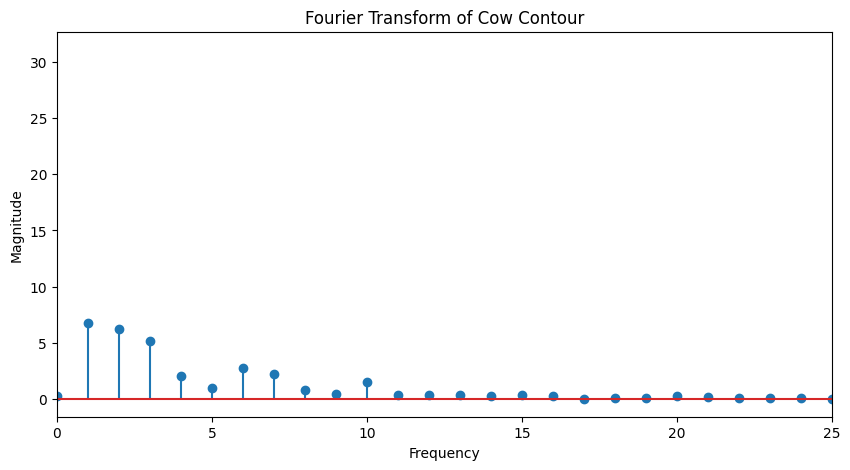

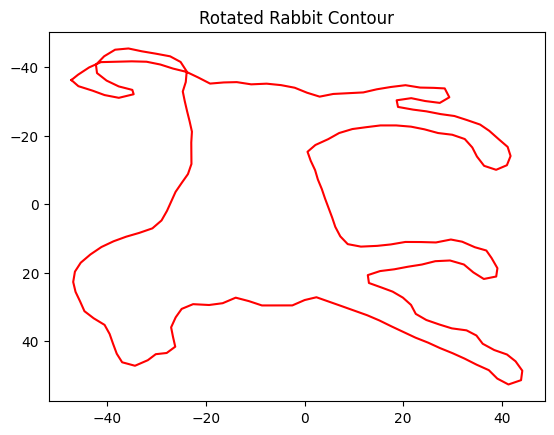

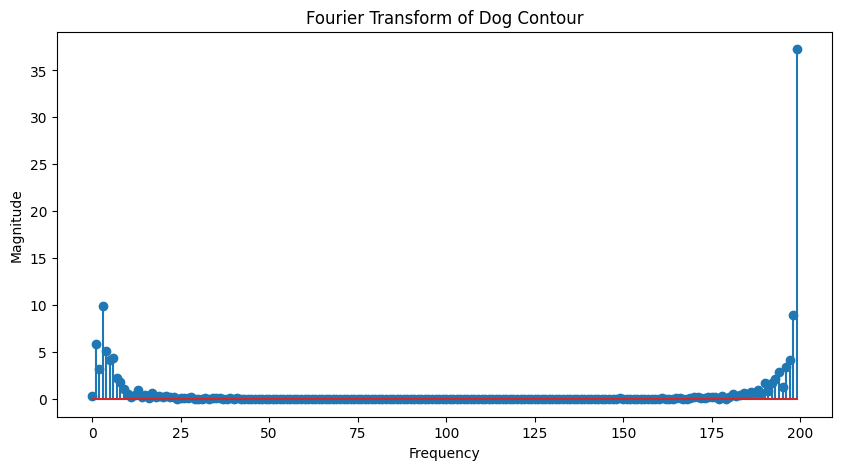

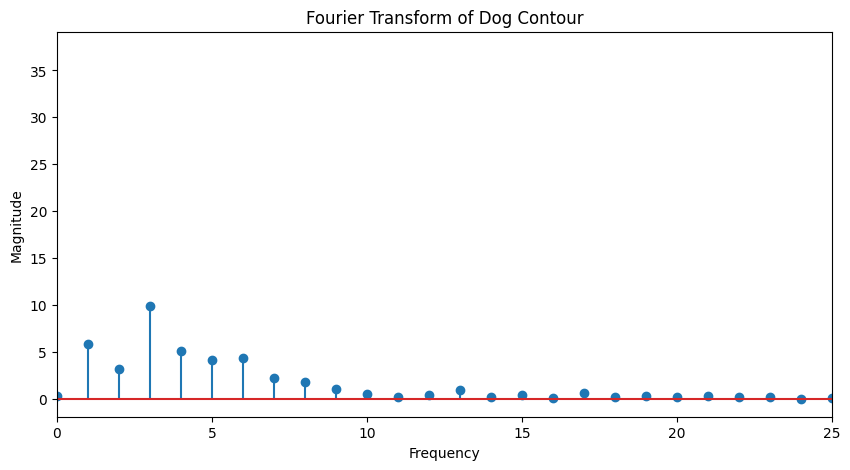

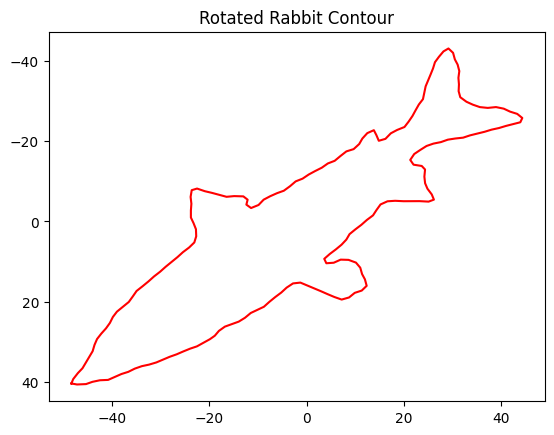

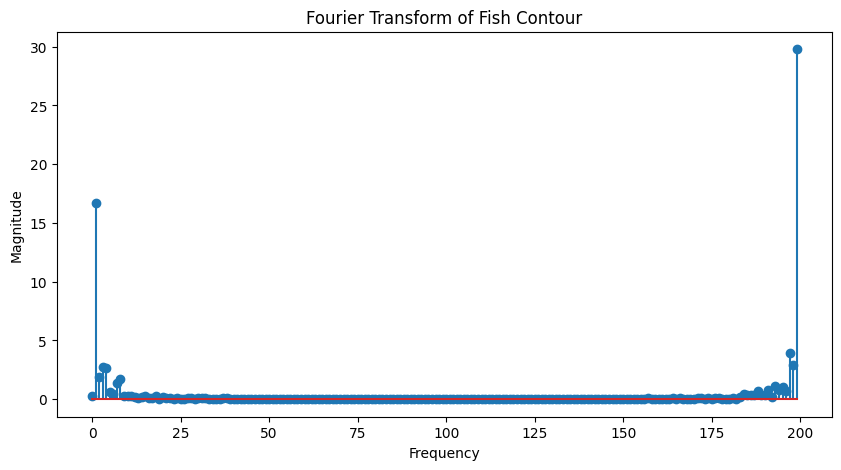

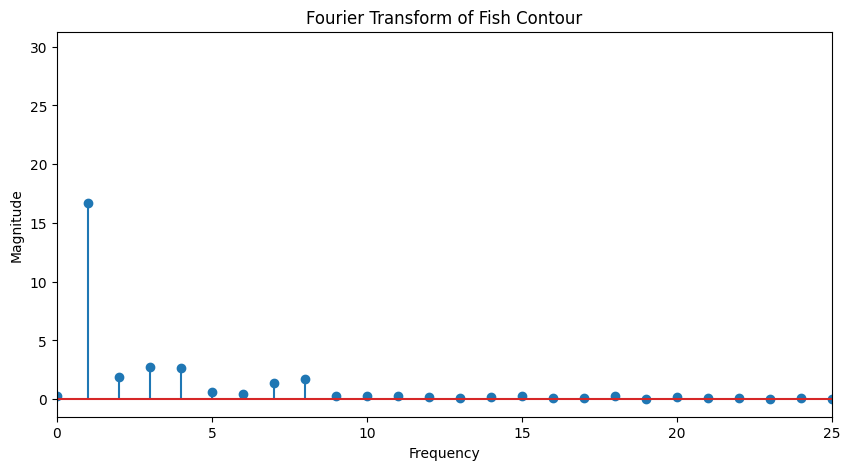

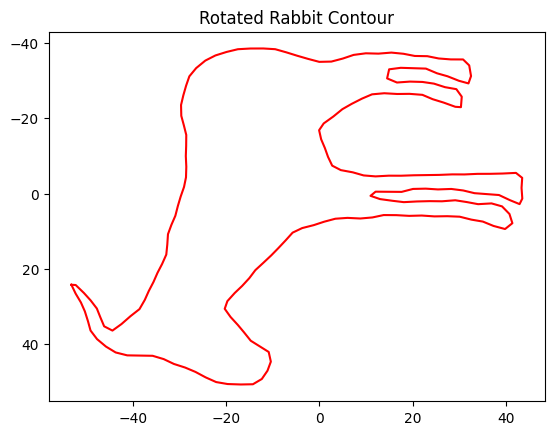

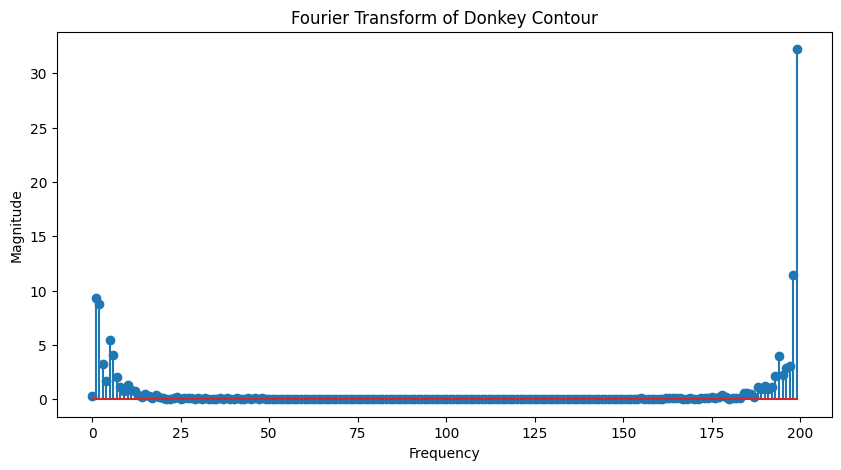

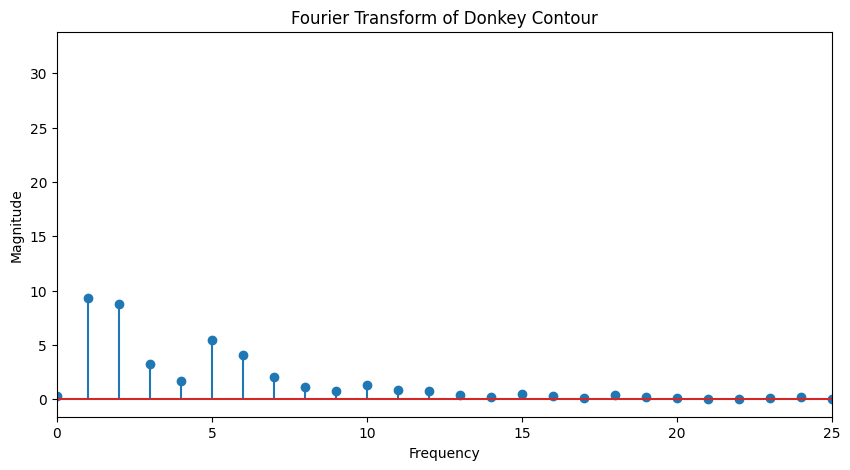

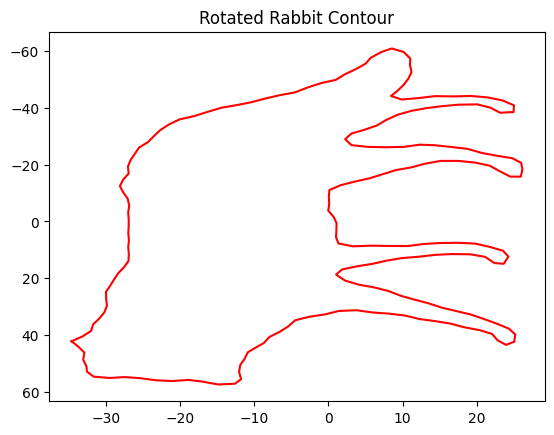

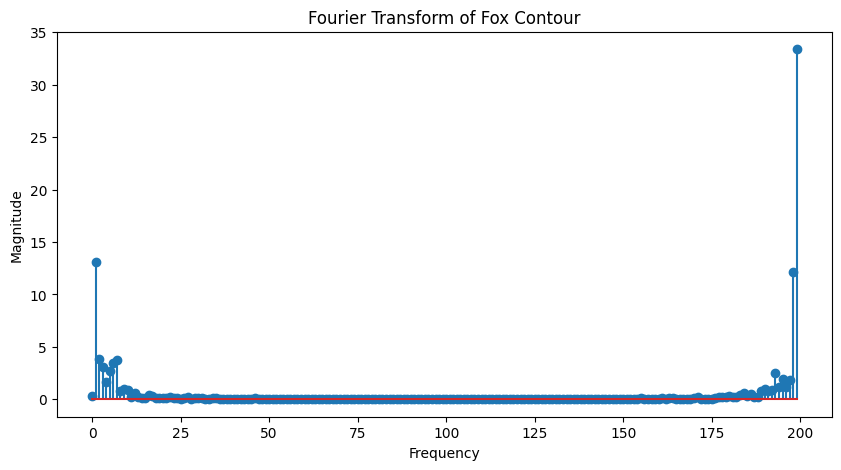

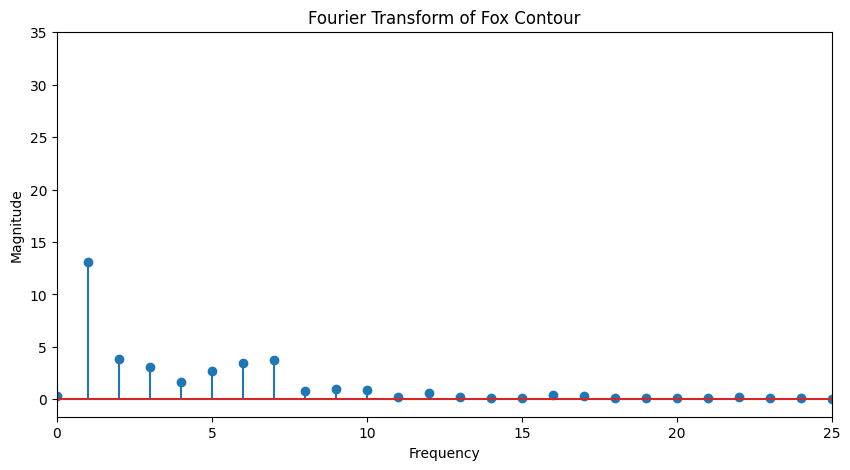

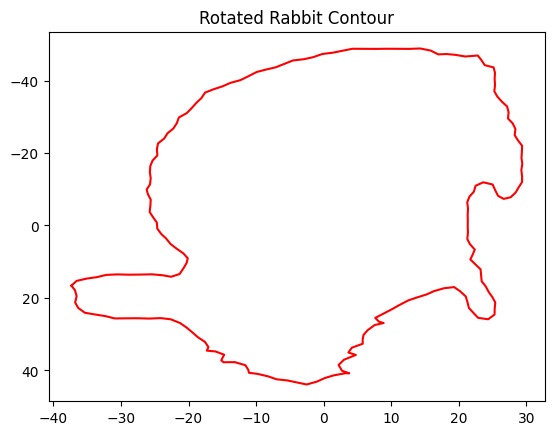

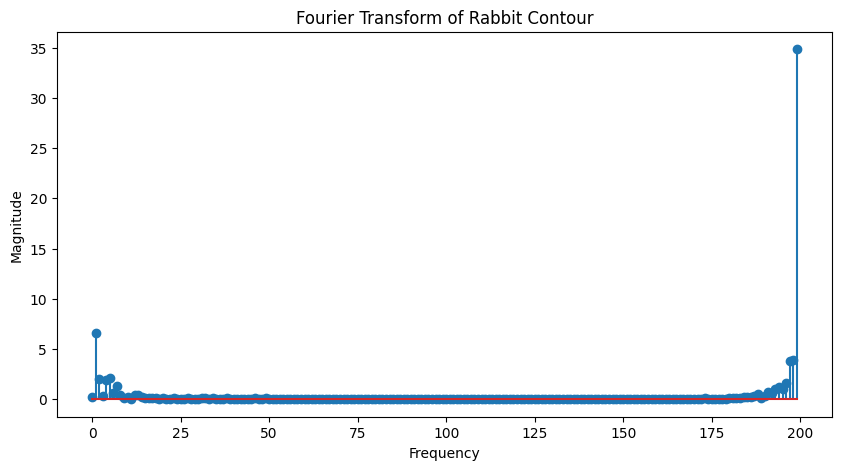

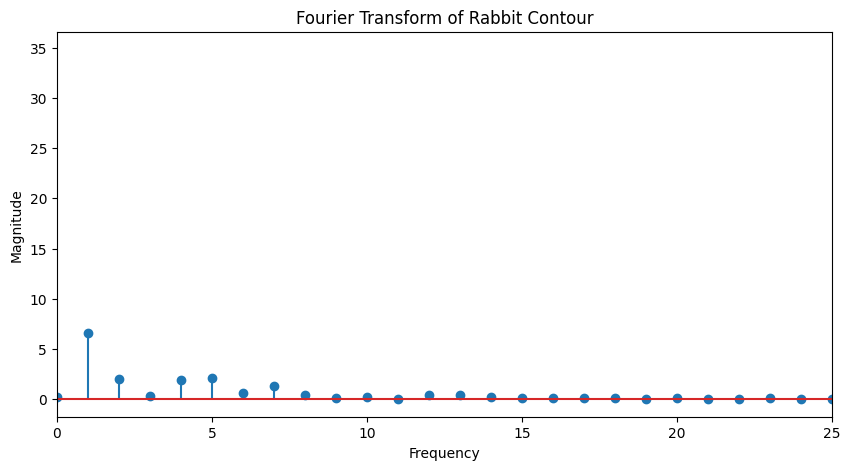

In [ ]:
import numpy as np
import cv2
from skimage import measure
import matplotlib.pyplot as plt
from pyefd import elliptic_fourier_descriptors
from scipy import linalg
from pyefd import reconstruct_contour


fft_list = []
for cont, animal in zip(contour_list, animal_list):

    contour_complex = np.array(cont, dtype=np.complex128)
    contour_complex = contour_complex[:, 1] - 1j * contour_complex[:, 0]

    plt.figure()
    plt.plot(cont[:, 1], -cont[:, 0],'r')
    plt.gca().invert_yaxis()
    plt.title('Rotated ' + file[:-4].capitalize() + ' Contour')
    # plt.xticks([])
    # plt.yticks([])
    plt.show()

    # Compute FFT
    fft_result = np.fft.fft(contour_complex) / 200

    fft_list.append(np.abs(fft_result))

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, 25)
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.show


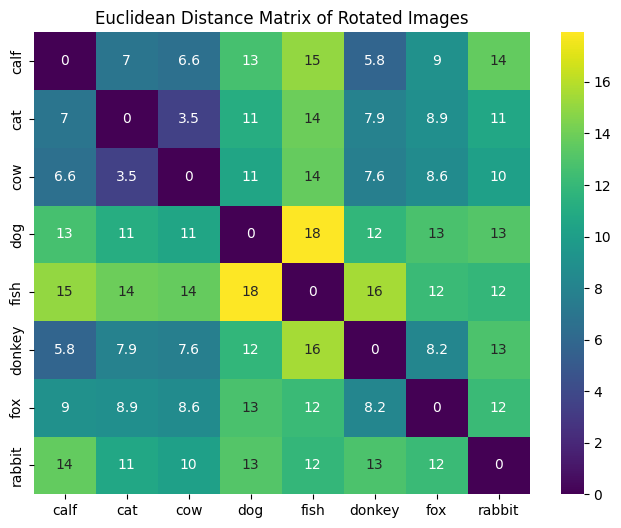

In [ ]:
# Plot the distance table
plot_euclidean_distance_table(fft_list, 'Euclidean Distance Matrix of Rotated Images')

# FD with rescale

['calf.png', 'cat.png', 'cow.png', 'dog.png', 'fish.png', 'donkey.png', 'fox.png', 'rabbit.png']
/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/calf.png


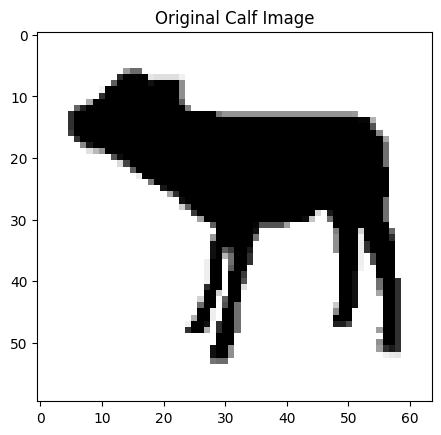

Number of points in Calf
150


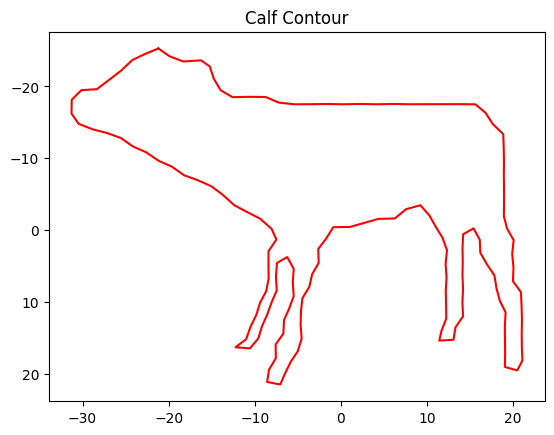

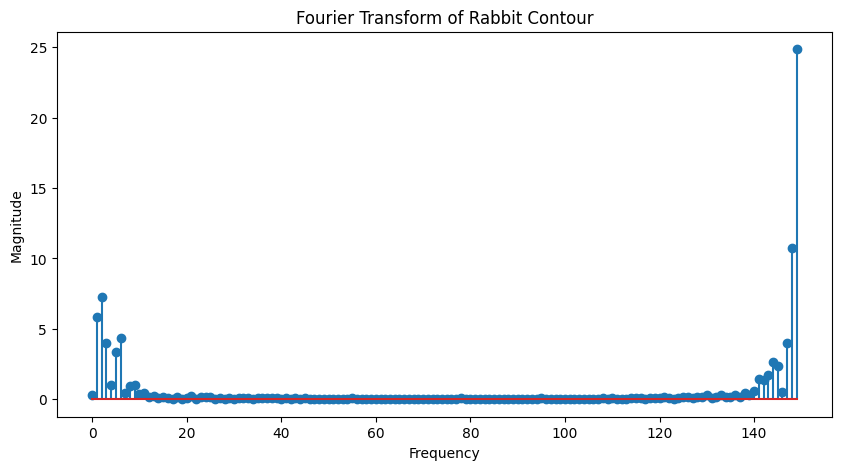

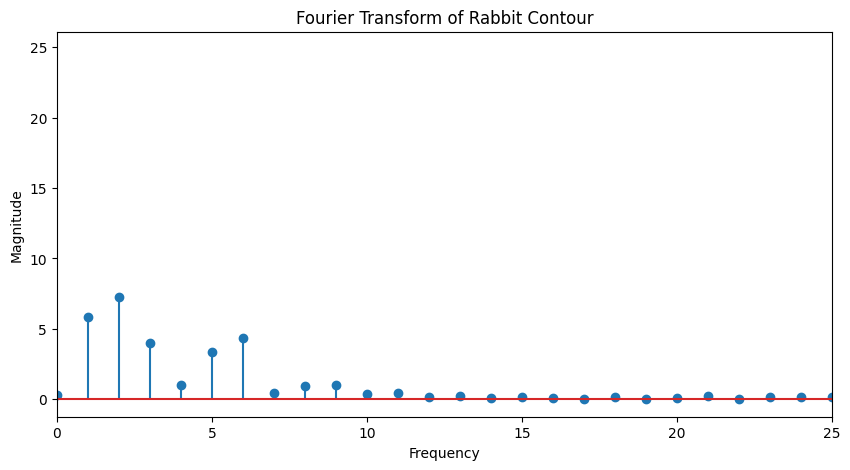

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cat.png


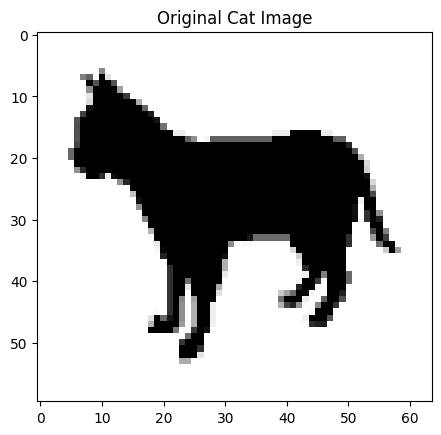

Number of points in Cat
150


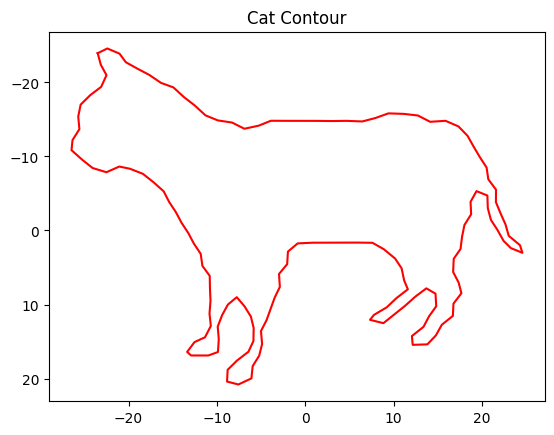

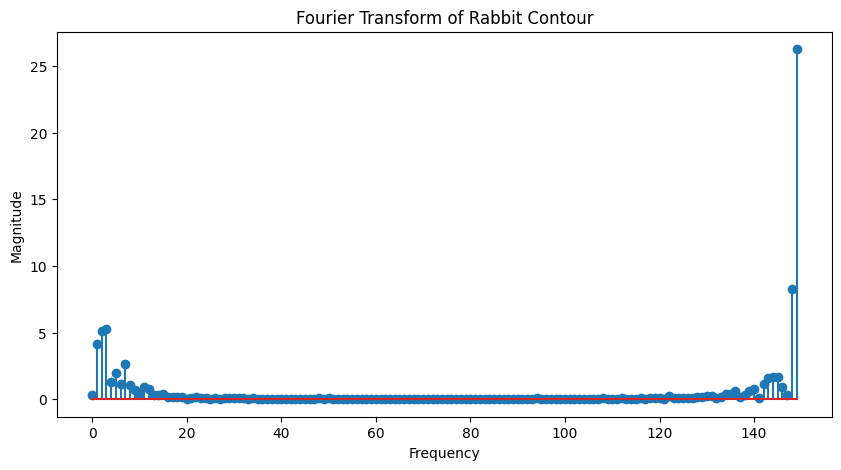

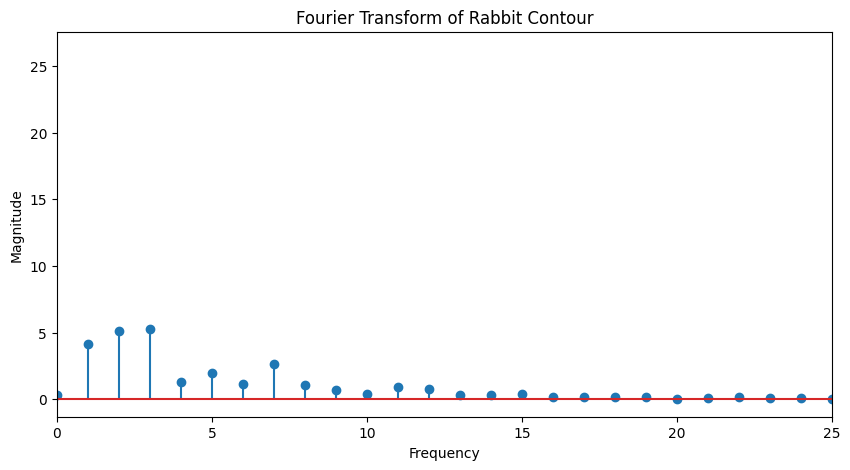

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cow.png


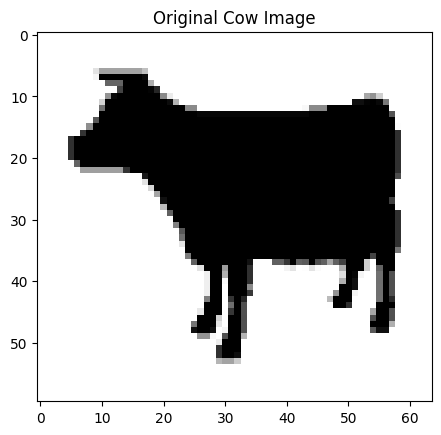

Number of points in Cow
150


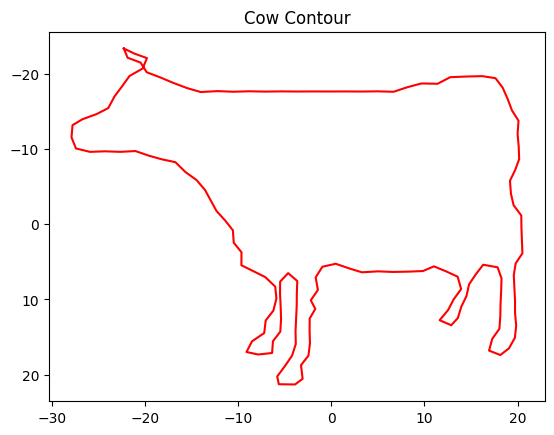

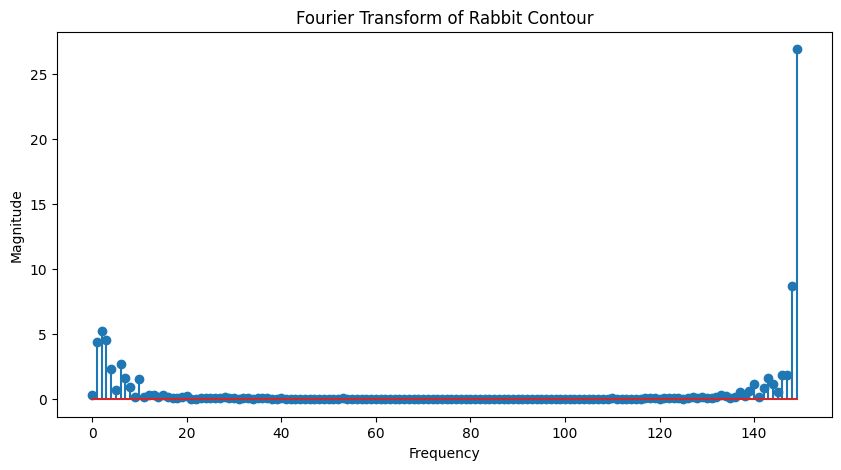

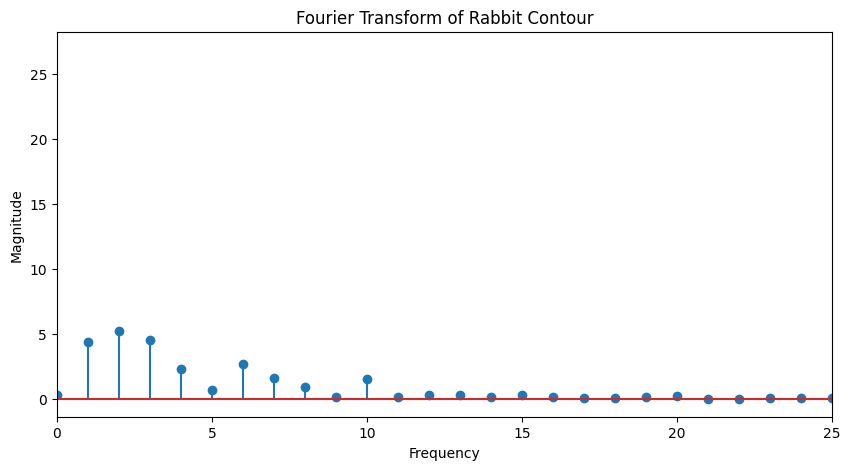

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/dog.png


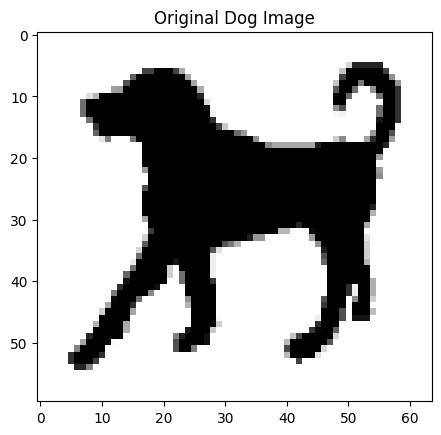

Number of points in Dog
150


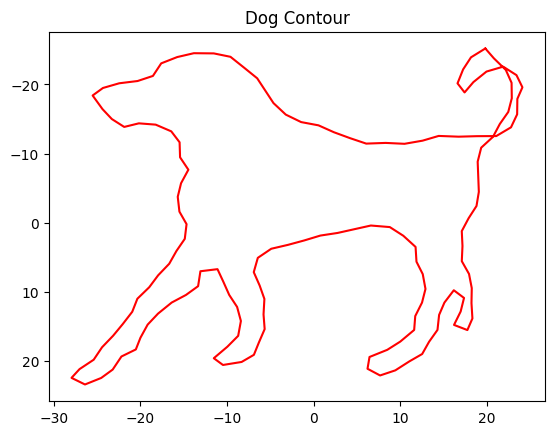

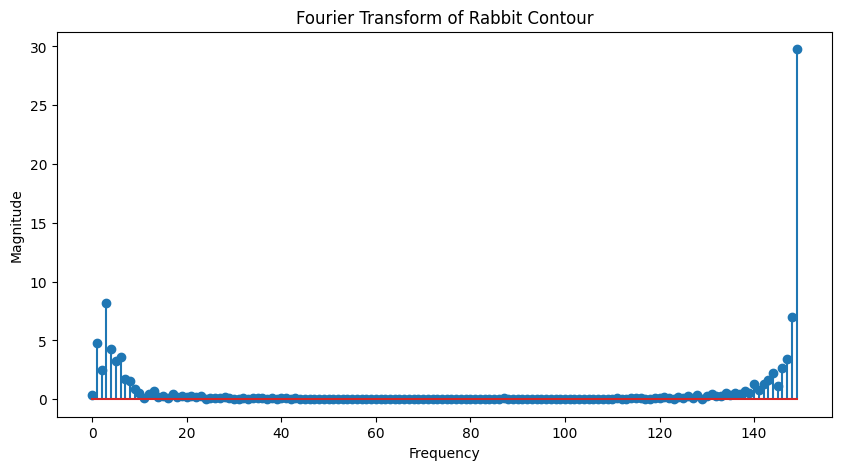

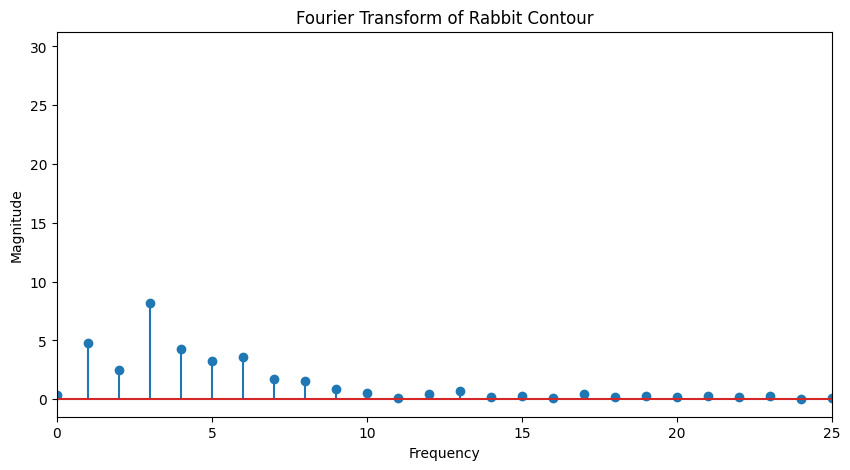

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fish.png


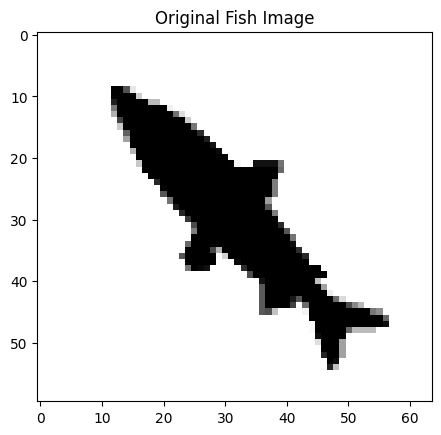

Number of points in Fish
150


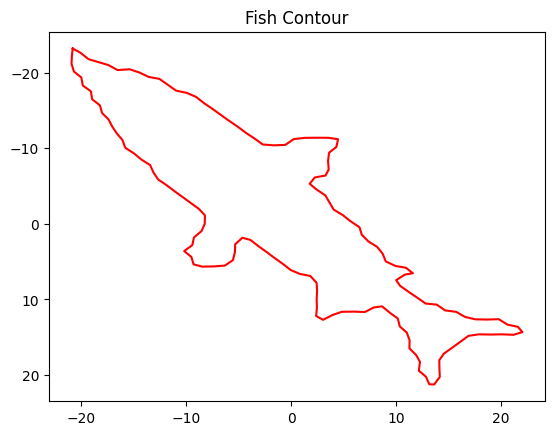

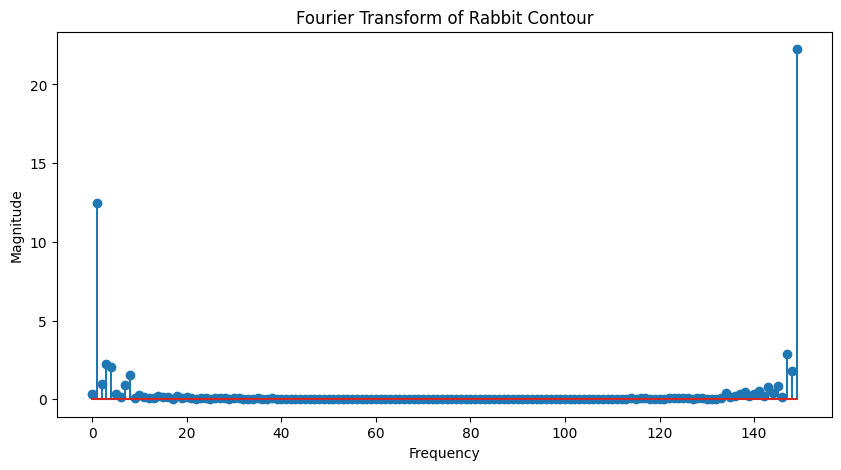

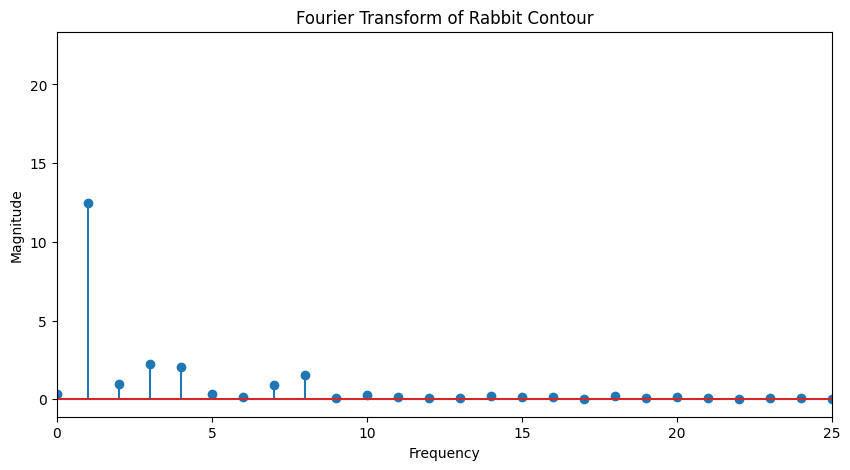

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/donkey.png


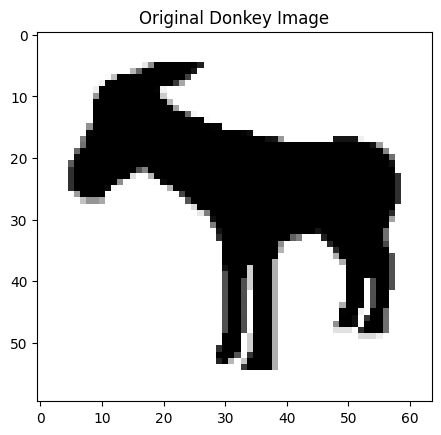

Number of points in Donkey
150


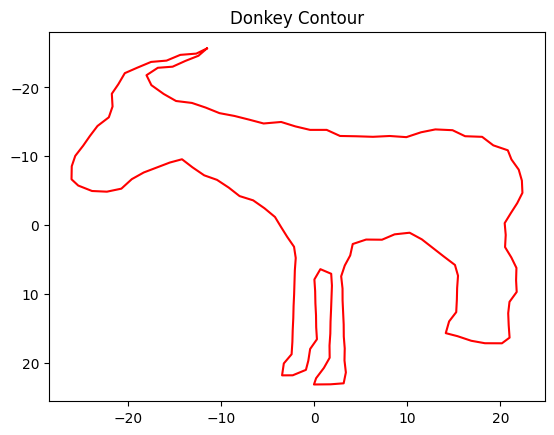

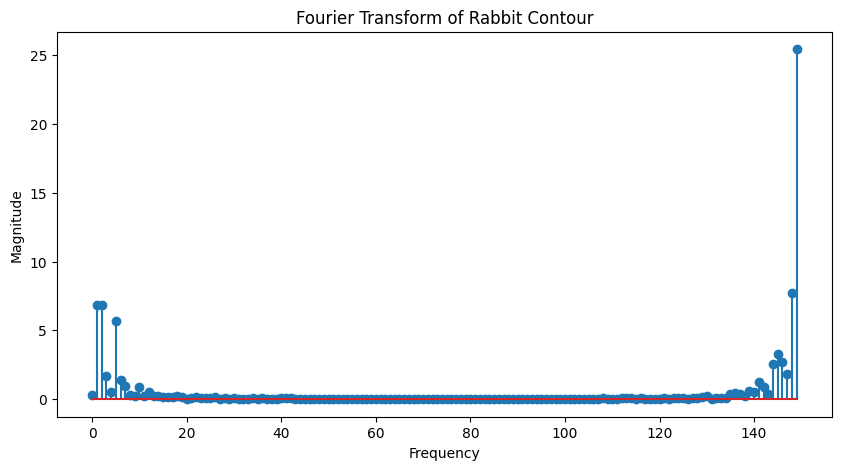

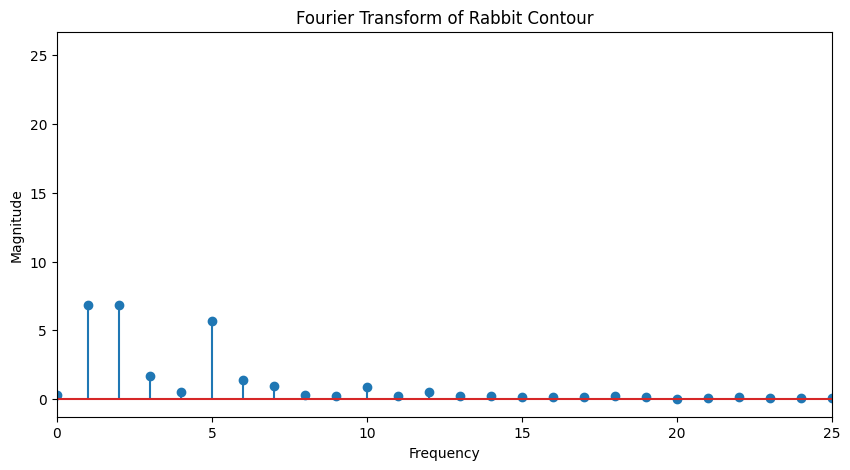

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fox.png


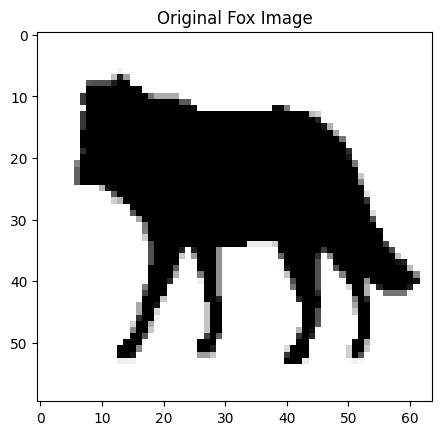

Number of points in Fox
150


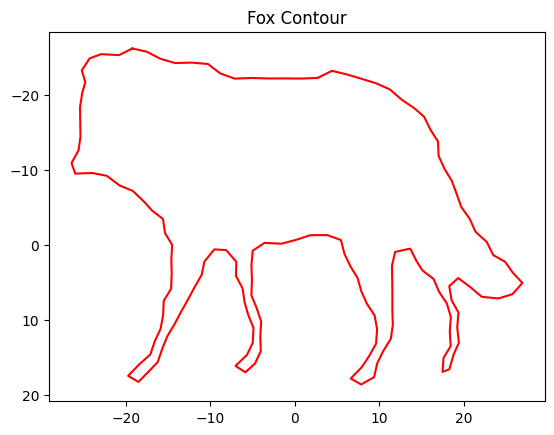

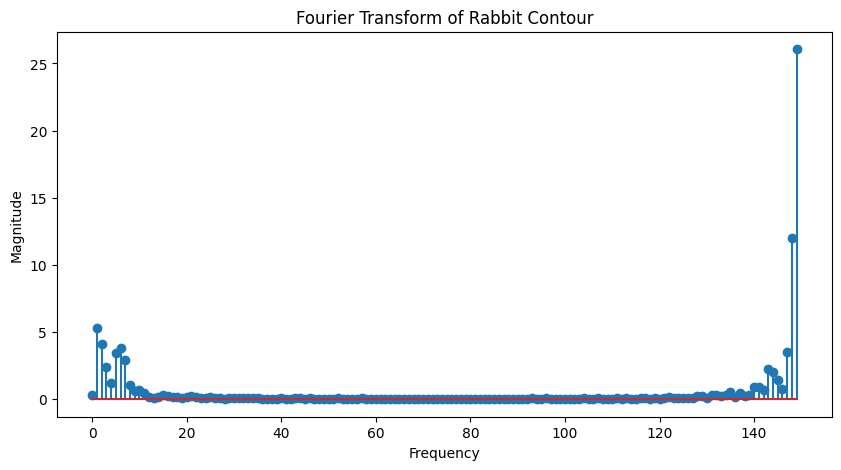

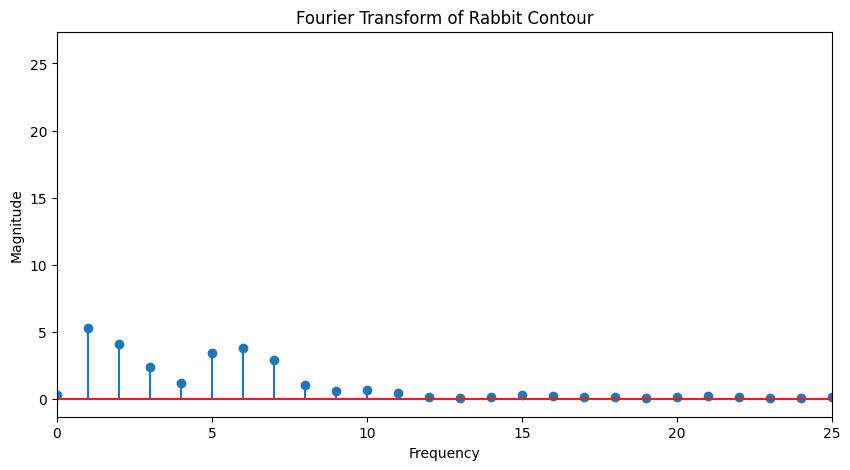

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/rabbit.png


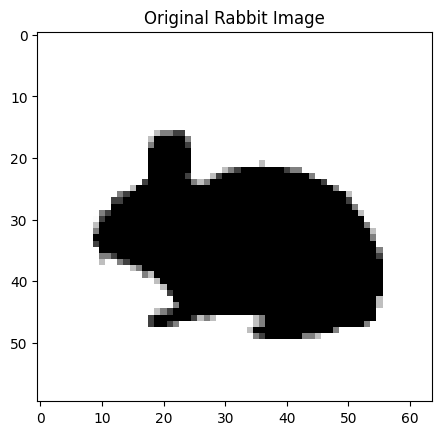

Number of points in Rabbit
150


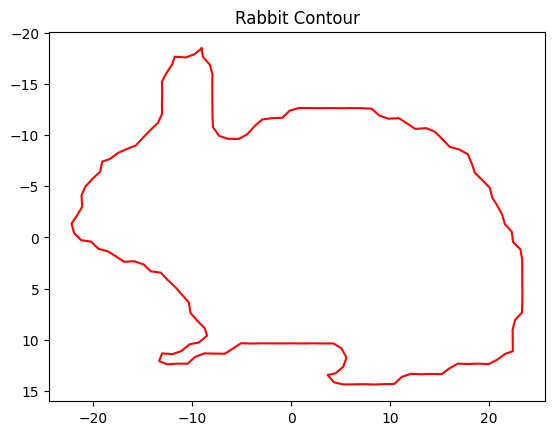

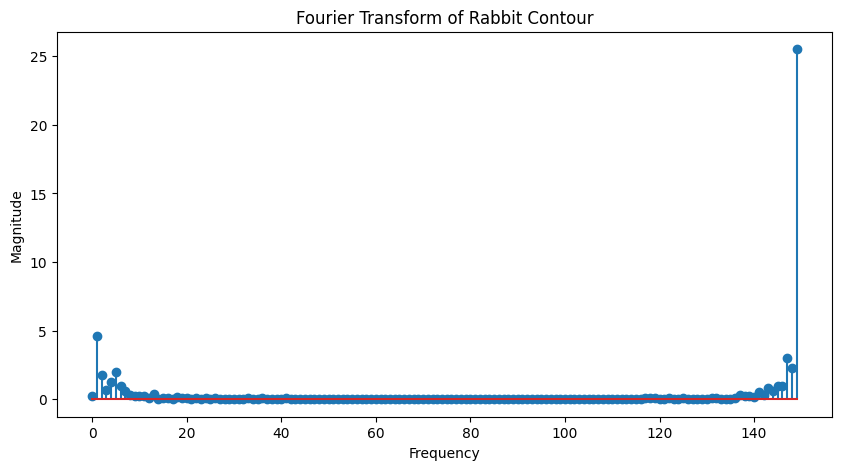

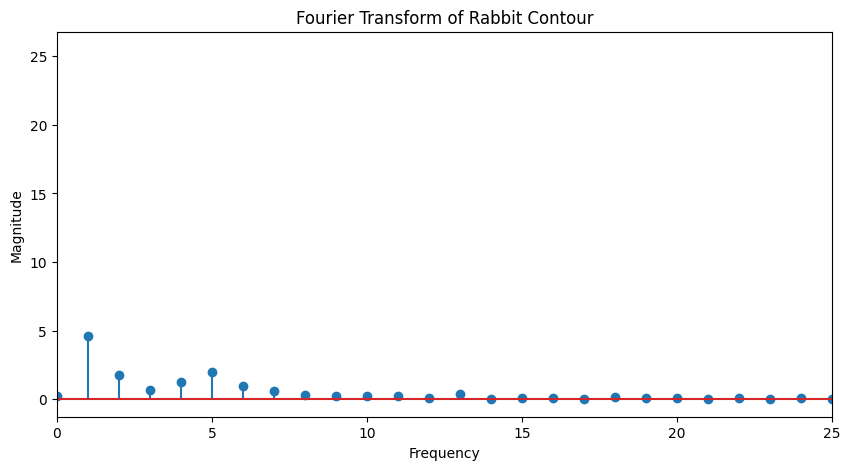

In [ ]:
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow
import cv2
import os
from pyefd import elliptic_fourier_descriptors
from scipy import linalg
from pyefd import reconstruct_contour


filelist = os.listdir(work_path + 'Data/Animal_Data/')
print(filelist)

fft_list = []

for file in filelist:
    print(work_path + 'Data/Animal_Data/' + file)
    img = cv2.imread(work_path + 'Data/Animal_Data/' + file, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (64, 60))

    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title('Original ' + file[:-4].capitalize() + ' Image')
    #plt.xticks([])
    #plt.yticks([])
    plt.show()

    _, binary_image = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # Find contours in the binary image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)

    coeffs = elliptic_fourier_descriptors(np.squeeze(contour), order=80)  # Adjust the order as needed

    reconstructed_contour = reconstruct_contour(coeffs, locus=(0, 0), num_points=150)
    print('Number of points in ' + file[:-4].capitalize())
    print(reconstructed_contour.shape[0])
    plt.figure()
    plt.plot(reconstructed_contour[:, 0], reconstructed_contour[:, 1],'r')
    plt.gca().invert_yaxis()
    plt.title(file[:-4].capitalize() + ' Contour')
    #plt.xticks([])
    #plt.yticks([])
    plt.show()

    contour_complex = np.array(reconstructed_contour, dtype=np.complex128)
    contour_complex = contour_complex[:, 0] + 1j * contour_complex[:, 1]

    # Compute FFT
    fft_result = np.fft.fft(contour_complex) / 100

    fft_list.append(np.abs(fft_result))

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, 25)
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.show()





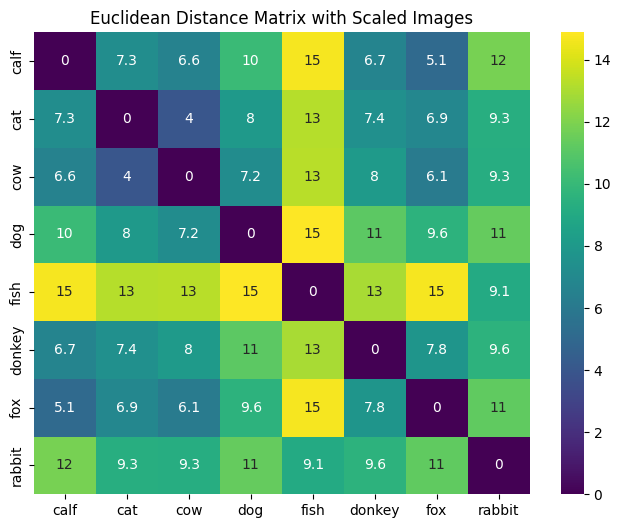

In [ ]:
# Plot the distance table
plot_euclidean_distance_table(fft_list, 'Euclidean Distance Matrix with Scaled Images')

# FD with noise

['calf.png', 'cat.png', 'cow.png', 'dog.png', 'fish.png', 'donkey.png', 'fox.png', 'rabbit.png']
/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/calf.png


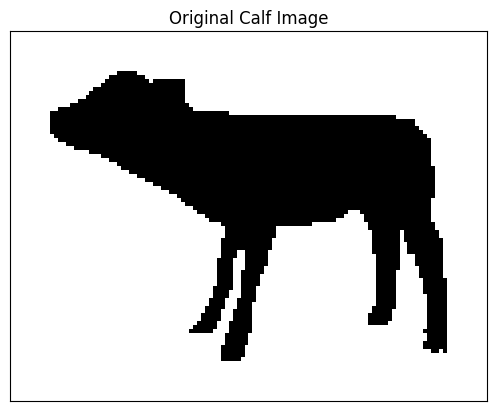

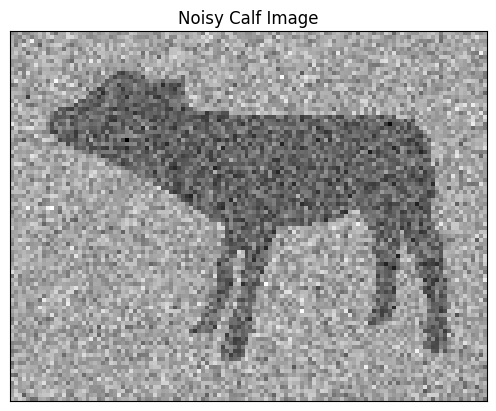

Number of points in Calf
200


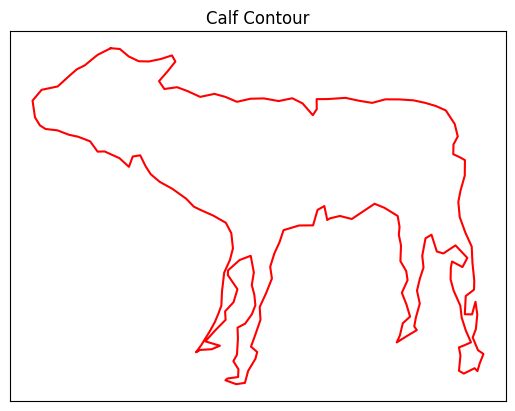

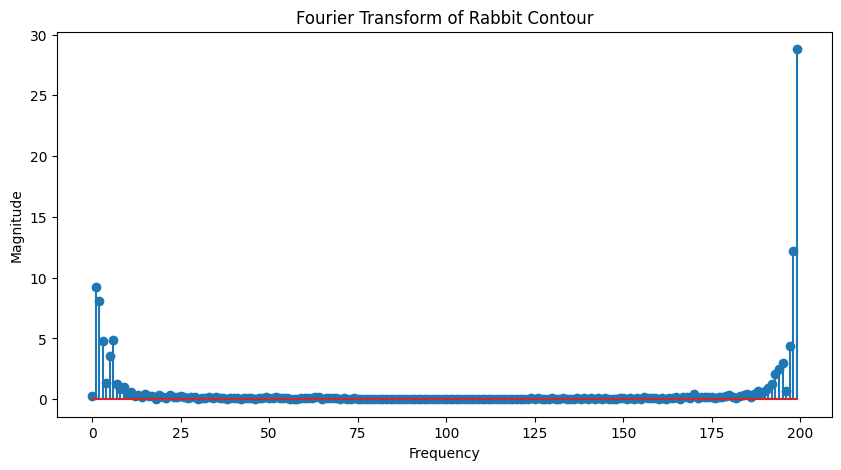

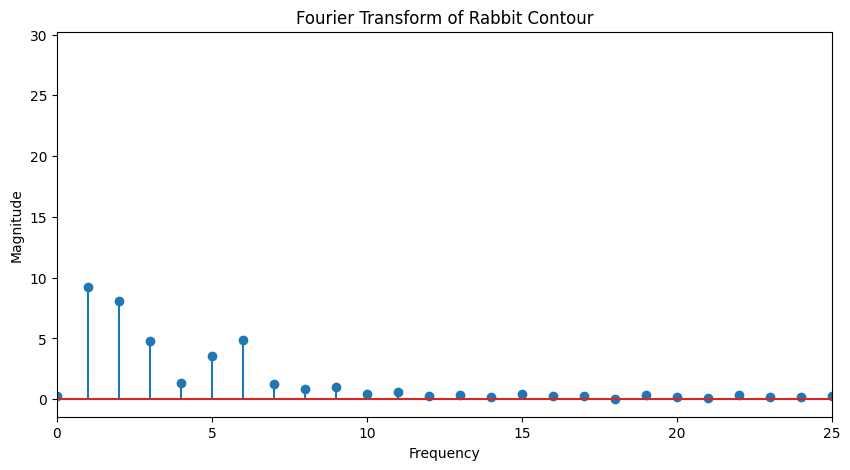

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cat.png


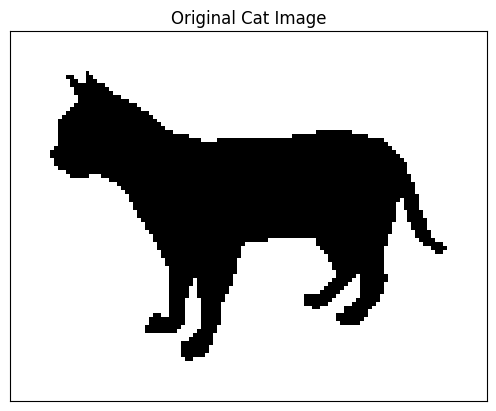

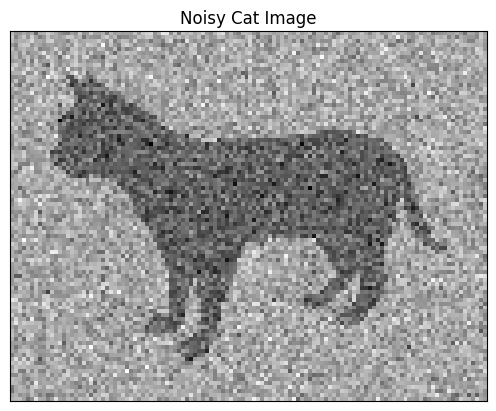

Number of points in Cat
200


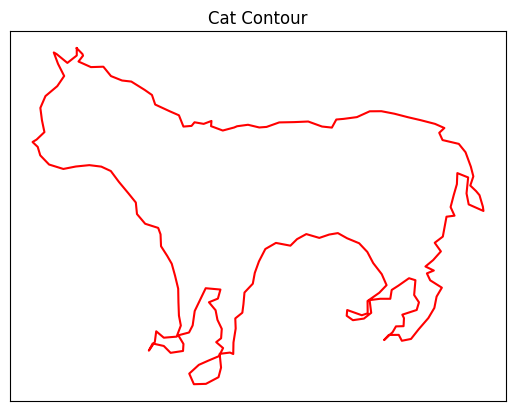

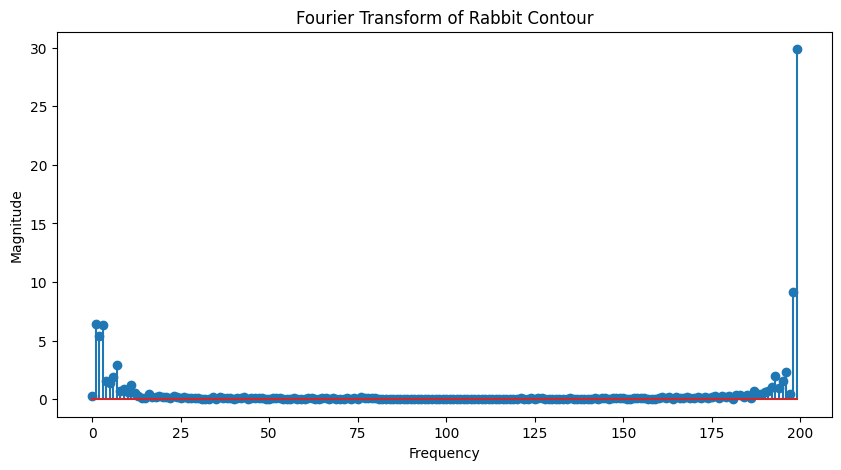

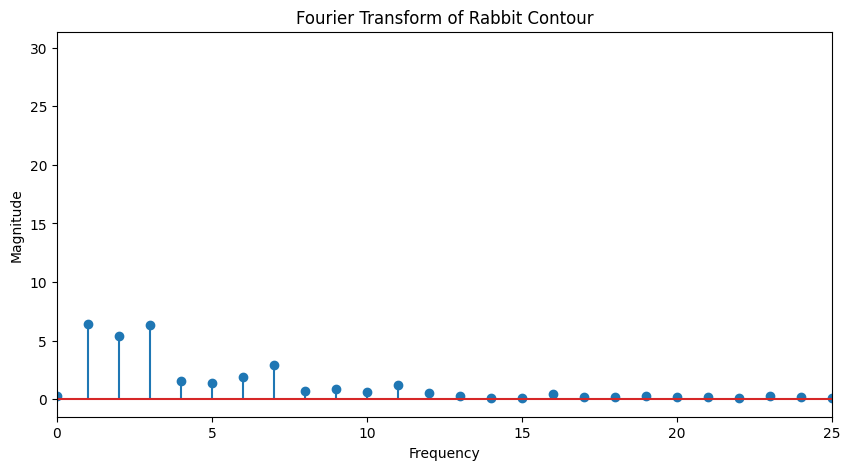

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/cow.png


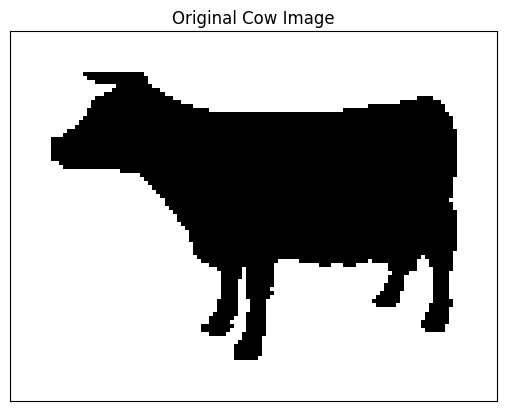

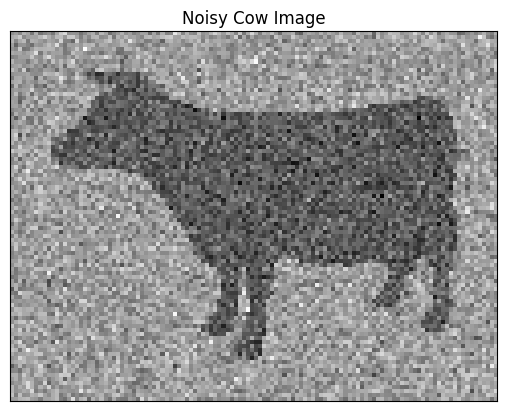

Number of points in Cow
200


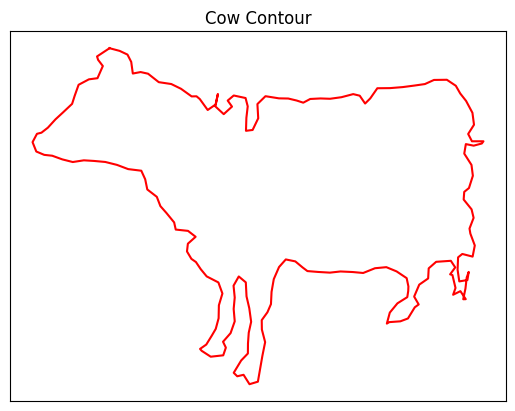

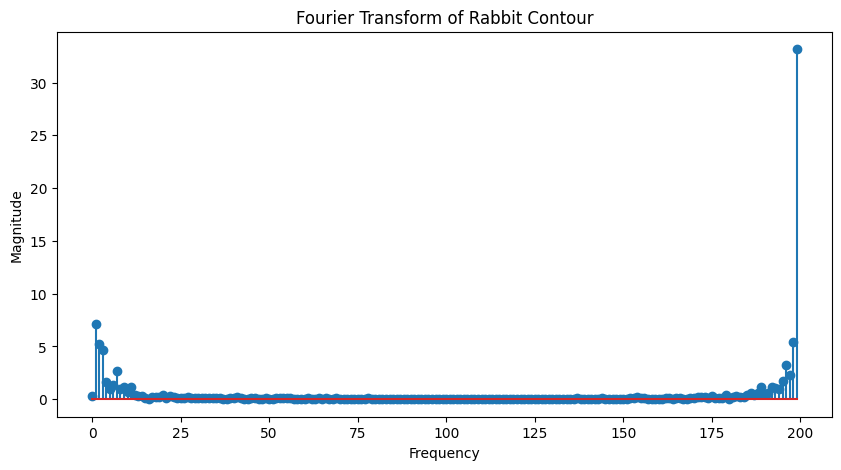

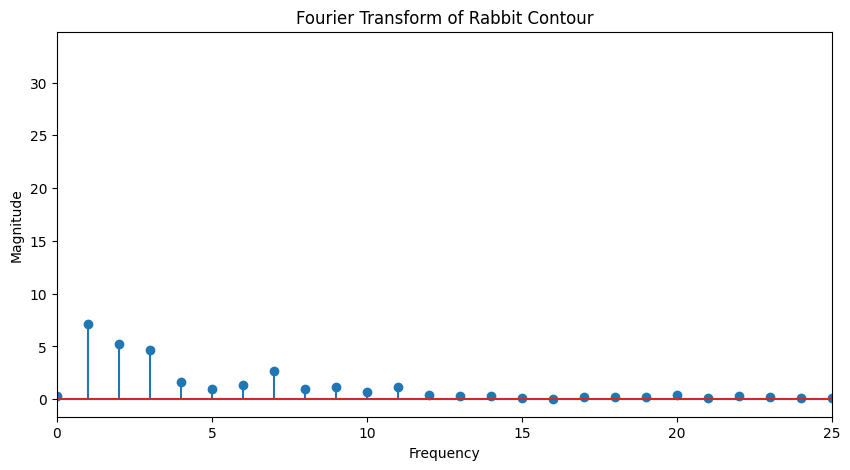

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/dog.png


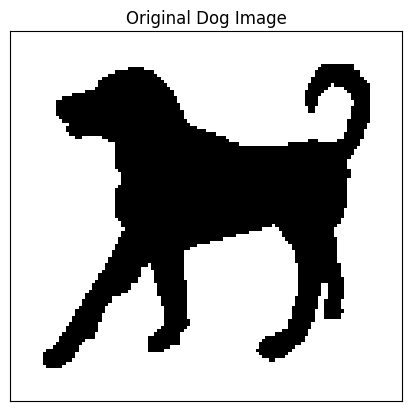

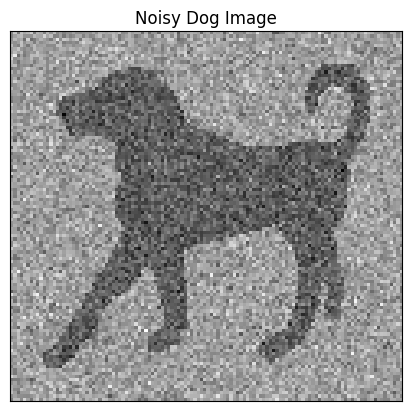

Number of points in Dog
200


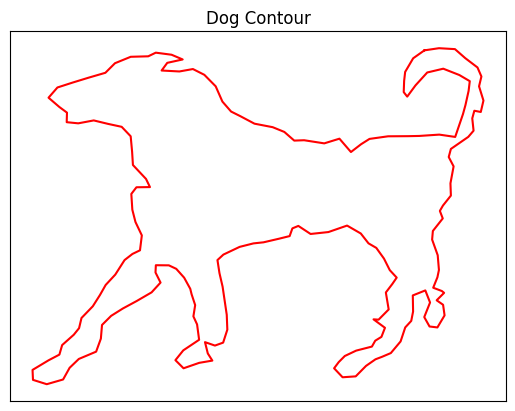

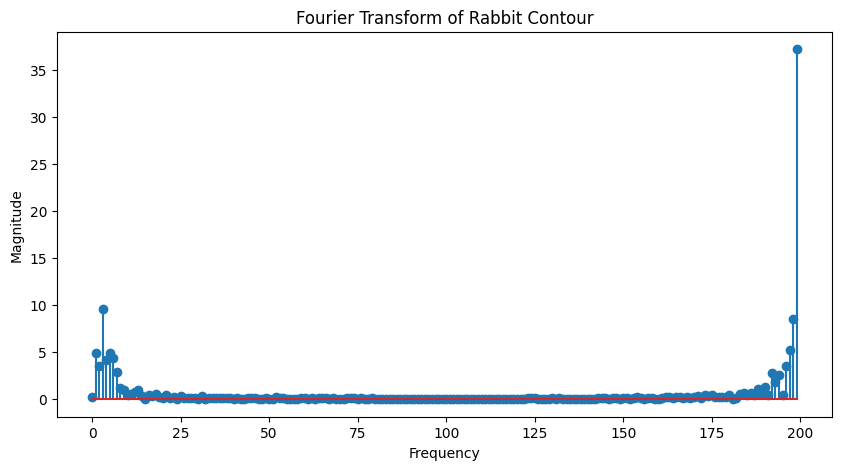

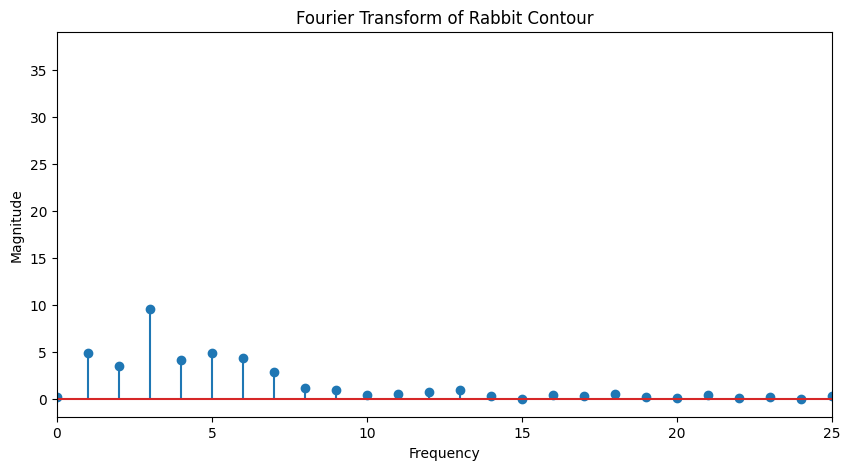

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fish.png


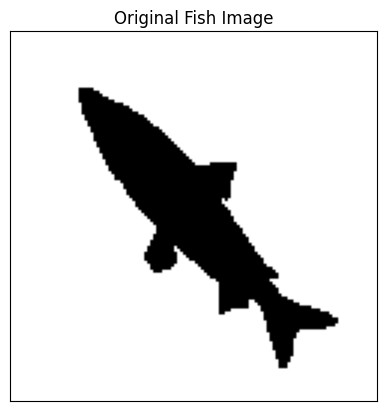

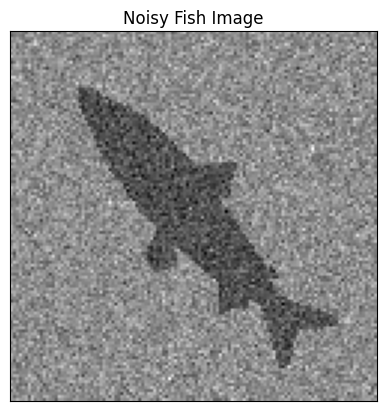

Number of points in Fish
200


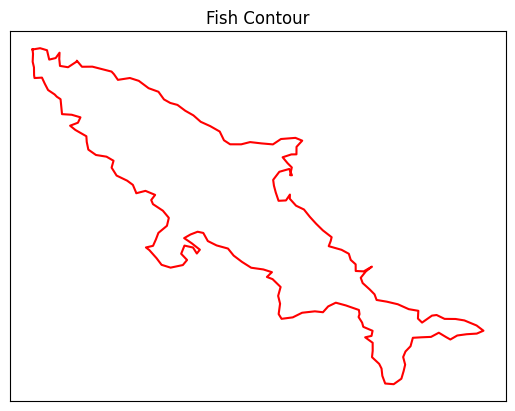

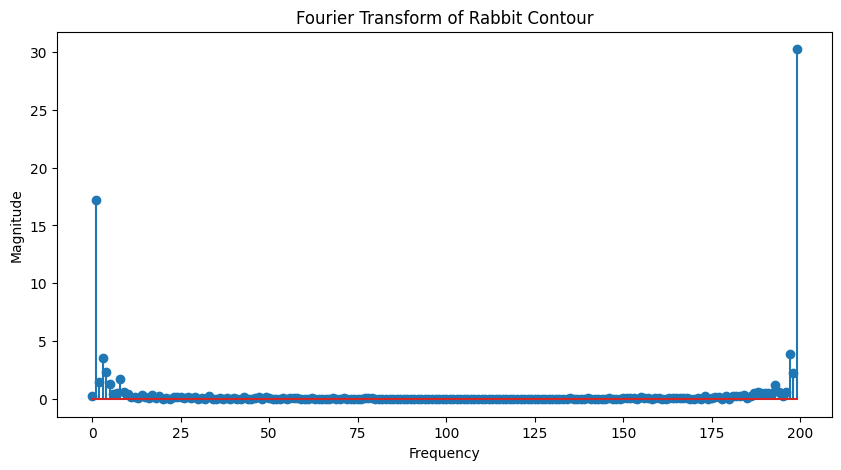

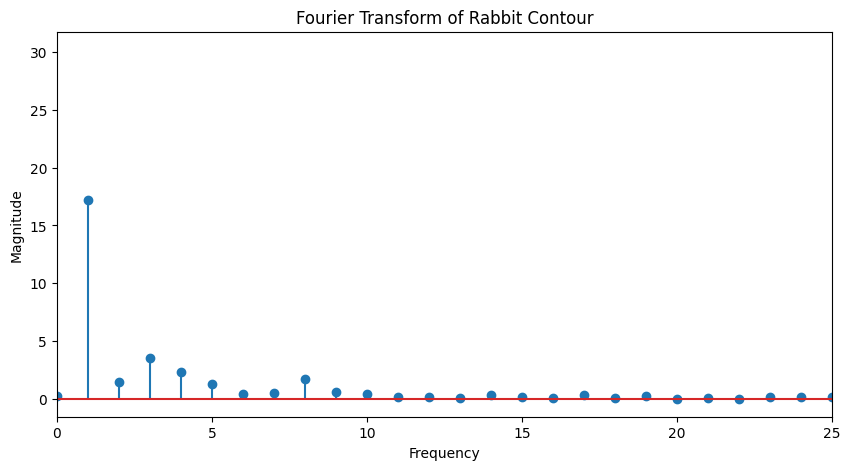

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/donkey.png


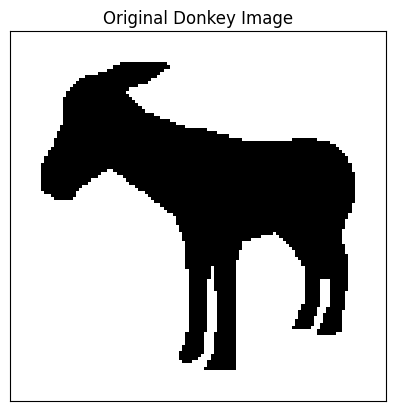

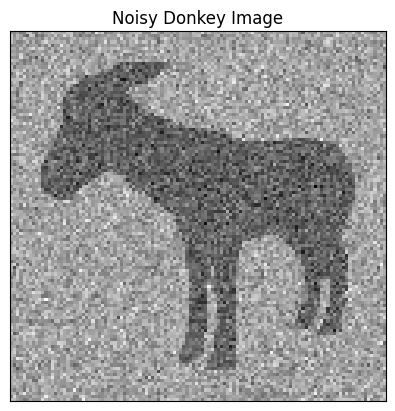

Number of points in Donkey
200


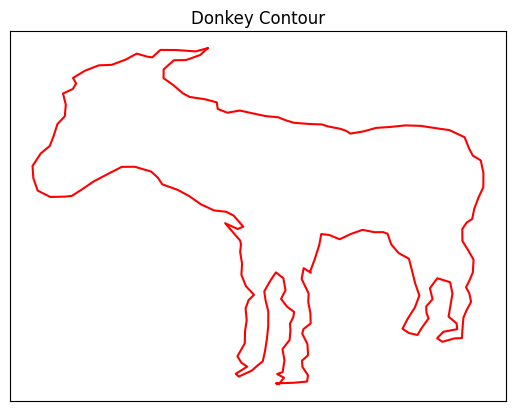

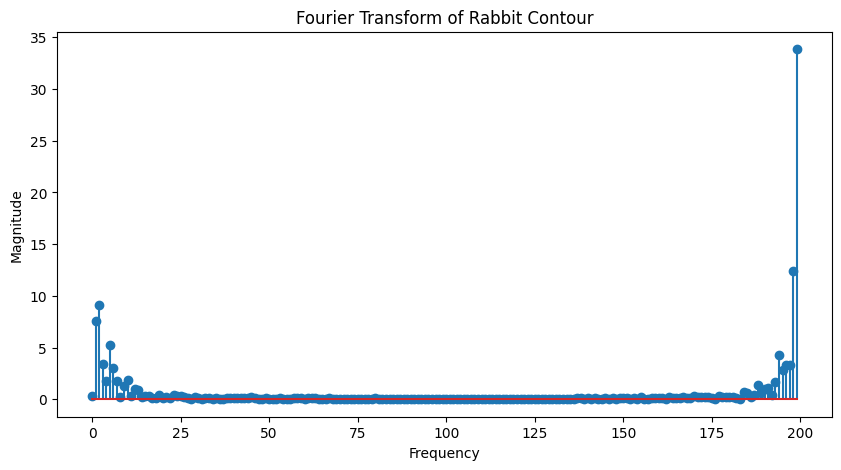

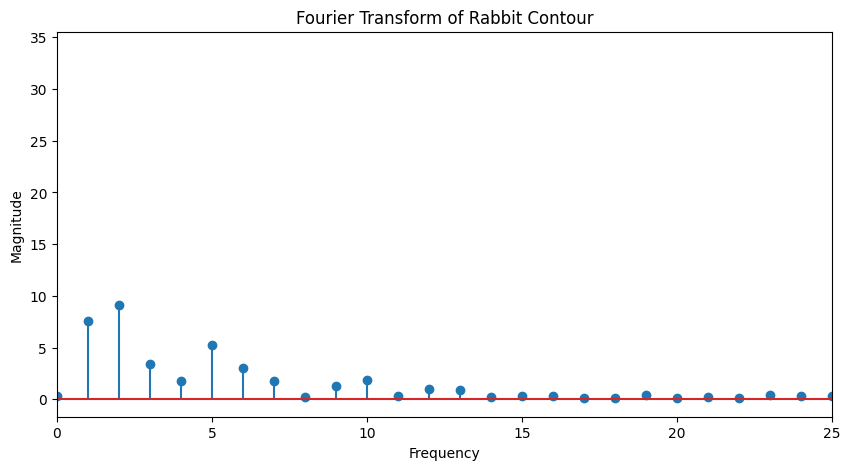

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/fox.png


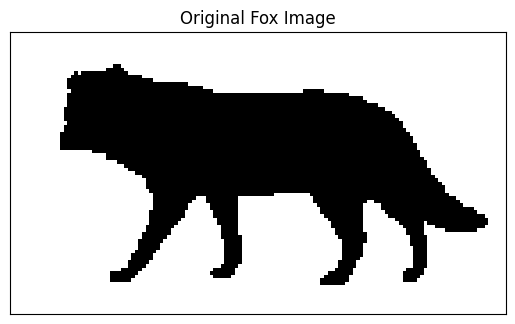

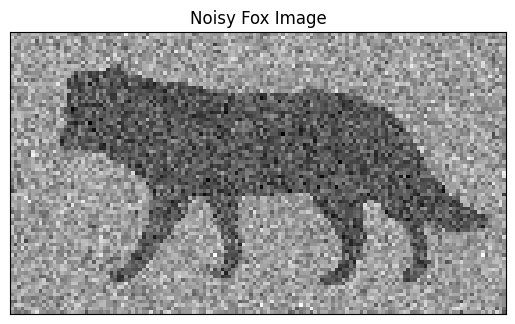

Number of points in Fox
200


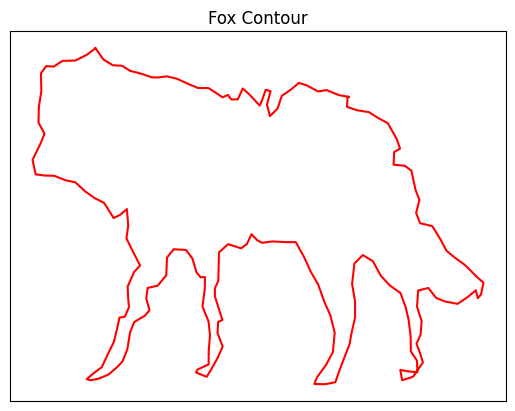

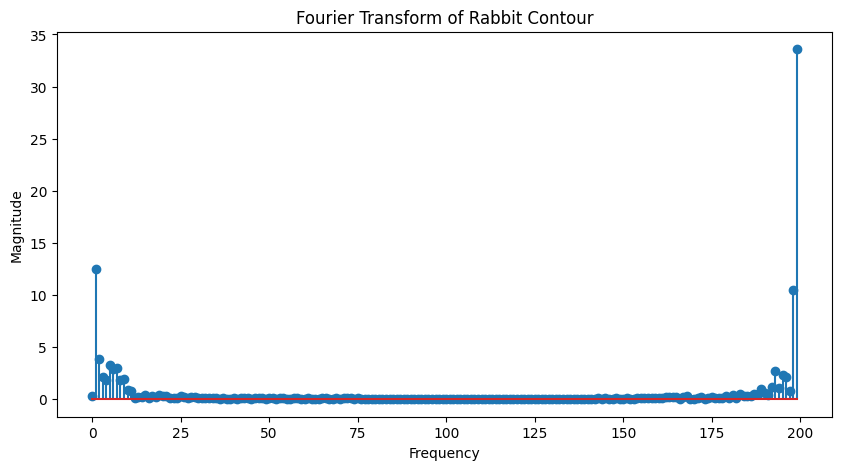

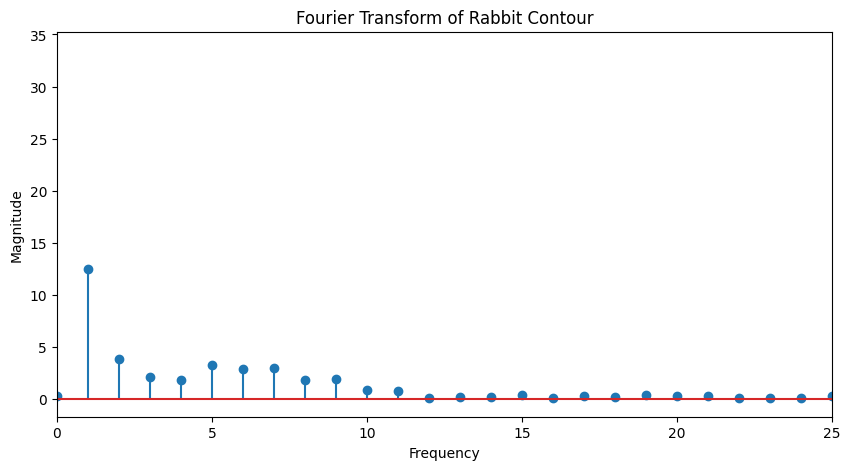

/content/drive/MyDrive/DigitalImageProcessing/Chapter13/Data/rabbit.png


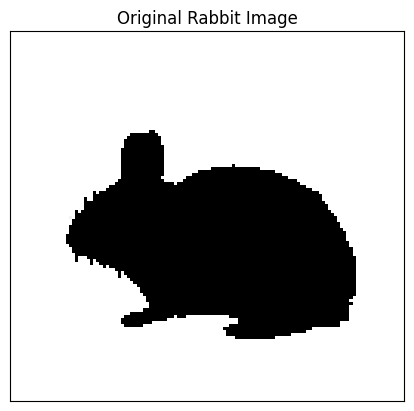

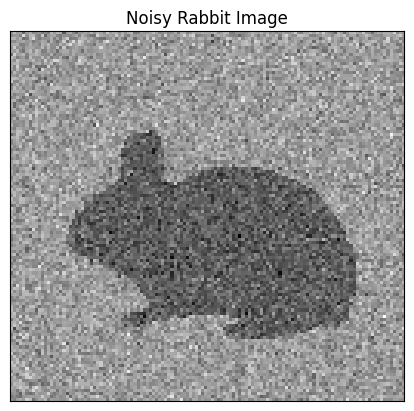

Number of points in Rabbit
200


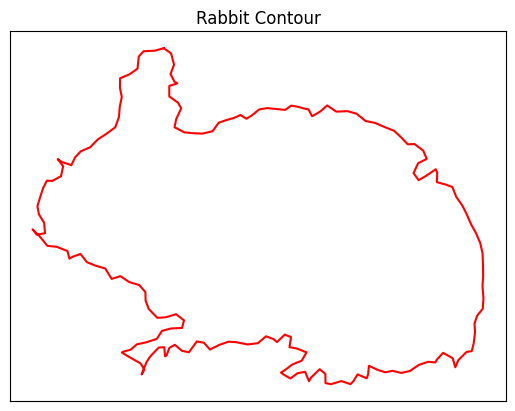

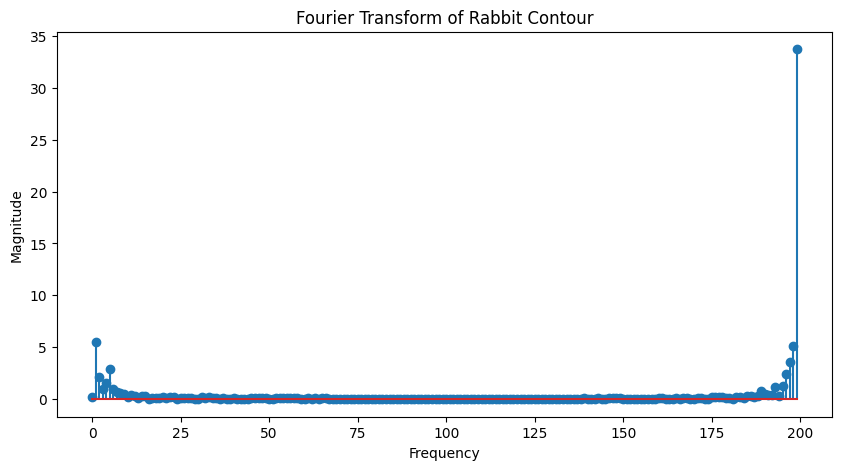

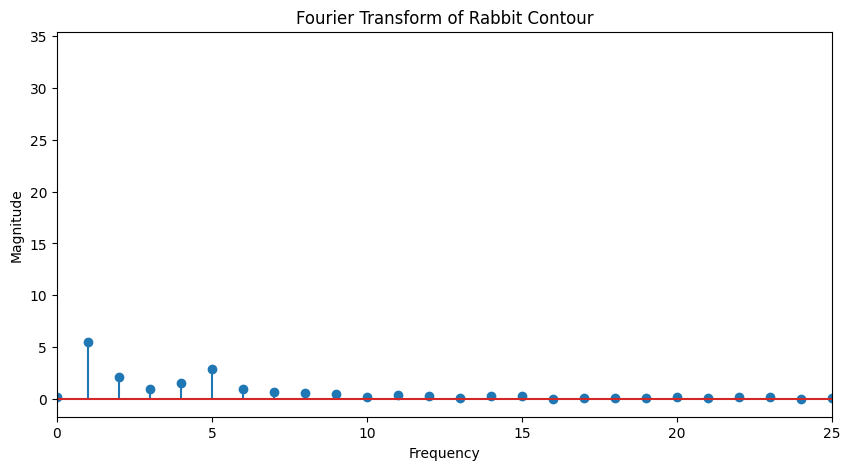

In [ ]:
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"
import matplotlib.pyplot as plt
import numpy as np
from google.colab.patches import cv2_imshow
import cv2
import os
from pyefd import elliptic_fourier_descriptors
from scipy import linalg
from pyefd import reconstruct_contour


filelist = os.listdir(work_path + 'Data/Animal_Data/')
print(filelist)

fft_list = []

for file in filelist:
    print(work_path + 'Data/Animal_Data/' + file)
    img = cv2.imread(work_path + 'Data/Animal_Data/' + file, cv2.IMREAD_GRAYSCALE)

    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title('Original ' + file[:-4].capitalize() + ' Image')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    noise = np.random.normal(70, 100, img.shape)
    noisy_image = img + noise

    plt.figure()
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Noisy ' + file[:-4].capitalize() + ' Image')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    _, noisy_image = cv2.threshold(noisy_image, 127, 255, cv2.THRESH_BINARY_INV)
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)



    # Find contours in the binary image
    contours, _ = cv2.findContours(noisy_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)

    coeffs = elliptic_fourier_descriptors(np.squeeze(contour), order=80)  # Adjust the order as needed

    reconstructed_contour = reconstruct_contour(coeffs, locus=(0, 0), num_points=200)
    print('Number of points in ' + file[:-4].capitalize())
    print(reconstructed_contour.shape[0])
    plt.figure()
    plt.plot(reconstructed_contour[:, 0], reconstructed_contour[:, 1],'r')
    plt.gca().invert_yaxis()
    plt.title(file[:-4].capitalize() + ' Contour')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    contour_complex = np.array(reconstructed_contour, dtype=np.complex128)
    contour_complex = contour_complex[:, 0] + 1j * contour_complex[:, 1]

    # Compute FFT
    fft_result = np.fft.fft(contour_complex) / 200

    fft_list.append(np.abs(fft_result))

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.figure(figsize=(10, 5))
    plt.stem(np.abs(fft_result))
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, 25)
    plt.title('Fourier Transform of ' + animal.capitalize() + ' Contour')

    plt.show()

noisy_fft = fft_list.copy()



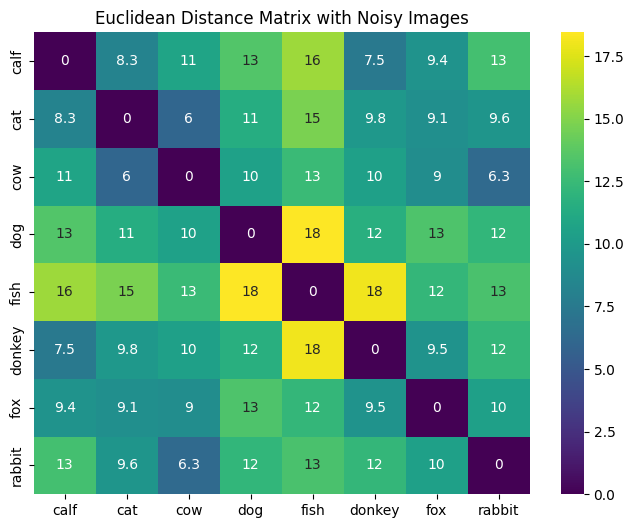

In [ ]:
# Plot the distance table
plot_euclidean_distance_table(fft_list, 'Euclidean Distance Matrix with Noisy Images')

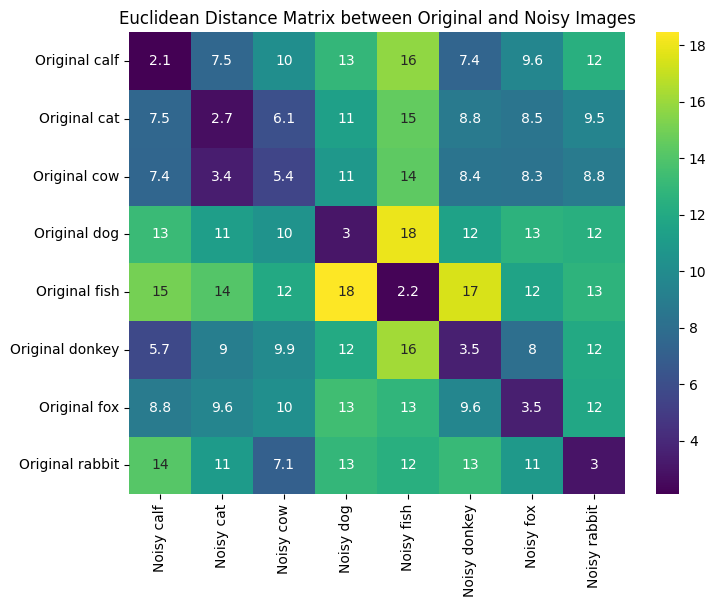

In [ ]:
def calculate_orginal_noisy(list1, list2):
    len1 = len(list1)
    len2 = len(list2)
    if len1 != len2:
        raise ValueError("Input lists must have the same length.")

    dis_matrix = np.zeros((len1, len2))
    for i in range(len(list1)):
        for j in range(len(list2)):
            dis_matrix[i, j] = np.linalg.norm(list1[i] - list2[j])

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(dis_matrix, annot=True, cmap="viridis")
    plt.title('Euclidean Distance Matrix between Original and Noisy Images')
    noisy_names = ['Noisy ' + x for x in animal_list]
    ori_names = ['Original ' + x for x in animal_list]
    plt.xticks([x + 0.5 for x in range(8)], noisy_names, rotation = 90)
    plt.yticks([x + 0.5 for x in range(8)], ori_names, rotation =0)
    plt.show()

calculate_orginal_noisy(original_fft, noisy_fft)
